# EpiCoV 2020

- Number of sequences: `200,524`
- Collection dates: 1 Jan 20 to 6 Jul 20

In [1]:
# General
import os
import pandas as pd
import numpy as np
from tqdm import tqdm

# Plotting libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Custom helpers
from utils import (standardize_country_name, get_continent, choropleth_continent,
choropleth_world, map_age_to_group, col_fillna, plot_dominant_choropleth, inclusion_exclusion,
standardize_vaccine_status, map_pat_status)

import warnings
warnings.filterwarnings("ignore")

In [2]:
YEAR = "2020"
CLOUD_DATA_FOLDER = os.path.expanduser("~/gcs-data/")
DATA_PATH = os.path.expanduser(os.path.join(CLOUD_DATA_FOLDER, f"Full_data/epicov_{YEAR}_200k.csv"))
if not os.path.exists(DATA_PATH):
    DATA_PATH = os.path.expanduser(os.path.join(CLOUD_DATA_FOLDER, f"Full_data/epicov_{YEAR}_200k.parquet"))
PLOTS_PATH = f"Fall25_plots/epicov_{YEAR}/"

os.makedirs(PLOTS_PATH, exist_ok=True)

The patient status is varying too much, let's standardize it using the AI model trained on manual annotaions by Dr. Miae Lee.

In [3]:
# For patient status mapping
df_pat1 = pd.read_csv(os.path.expanduser(f"~/gcs-data/Full_data/models/patient_status_mapped_AI_20Dec25_v2.csv"))
df_pat1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201 entries, 0 to 200
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   patient_status     200 non-null    object
 1   clinical_status    201 non-null    object
 2   hospital_status    201 non-null    object
 3   severity           201 non-null    object
 4   who_category       201 non-null    object
 5   patient_status_en  201 non-null    object
 6   source_lang        201 non-null    object
 7   word_count         201 non-null    int64 
 8   bi_gru_status      201 non-null    object
 9   bi_gru_hosp        201 non-null    object
 10  bi_gru_severity    201 non-null    object
 11  bi_gru_category    201 non-null    object
 12  gemma_status       201 non-null    object
 13  gemma_hosp         201 non-null    object
 14  gemma_severity     201 non-null    object
 15  gemma_category     201 non-null    object
dtypes: int64(1), object(15)
memory usage: 25.3+ 

In [4]:
%%time
df = pd.read_csv(DATA_PATH) if DATA_PATH.endswith(".csv") else pd.read_parquet(DATA_PATH)
df.sort_values(by=["Collection date"], inplace=True)
df.shape, df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 200524 entries, 8434 to 200523
Data columns (total 18 columns):
 #   Column                           Non-Null Count   Dtype 
---  ------                           --------------   ----- 
 0   Accession ID                     200524 non-null  object
 1   Submission date                  200524 non-null  object
 2   Virus name                       200524 non-null  object
 3   Collection date                  200524 non-null  object
 4   Location                         200524 non-null  object
 5   Host                             200524 non-null  object
 6   Additional location information  6210 non-null    object
 7   Sampling strategy                11252 non-null   object
 8   Gender                           200524 non-null  object
 9   Patient age                      200519 non-null  object
 10  Patient status                   200509 non-null  object
 11  Last vaccinated                  76 non-null      object
 12  Passage           

((200524, 18), None)

In [5]:
df.nunique()

Accession ID                       200524
Submission date                      1016
Virus name                         200478
Collection date                       188
Location                             4418
Host                                    1
Additional location information      1035
Sampling strategy                     111
Gender                                133
Patient age                           311
Patient status                        133
Last vaccinated                        12
Passage                               103
Specimen                              329
Additional host information           417
Lineage                               946
Clade                                  11
AA Substitutions                    70260
dtype: int64

## Clean the data

Let's fill in missing values, fix spurious values and standardize a few column values

### Gender

In [6]:
df["Gender"].value_counts()

Gender
unknown    126740
Male        38933
Female      34391
49.0           17
unknowm        15
            ...  
64              1
9               1
13              1
62.0            1
23.0            1
Name: count, Length: 133, dtype: int64

In [7]:
[x for x in df["Patient status"].unique() if str(x)[0].isdigit()], [x for x in df["Gender"].unique() if str(x)[0].isdigit()]

([],
 ['3.0',
  '66.0',
  '57.0',
  '69.0',
  '76.0',
  '38.0',
  '63.0',
  '65',
  '58.0',
  '41.0',
  '37.0',
  '34.0',
  '64.0',
  '49.0',
  '31.0',
  '46.0',
  '17.0',
  '39.0',
  '47.0',
  '74.0',
  '42.0',
  '48.0',
  '35.0',
  '79.0',
  '65.0',
  '60.0',
  '33.0',
  '32.0',
  '24.0',
  '68.0',
  '75.0',
  '29.0',
  '52.0',
  '73.0',
  '40.0',
  '26.0',
  '70.0',
  '53.0',
  '22.0',
  '45.0',
  '50.0',
  '92.0',
  '25.0',
  '27.0',
  '21.0',
  '59.0',
  '16.0',
  '41',
  '59',
  '47',
  '46',
  '30',
  '53',
  '25',
  '20',
  '18.0',
  '12',
  '33',
  '55',
  '28.0',
  '36.0',
  '44',
  '20.0',
  '51.0',
  '19.0',
  '51',
  '57',
  '43',
  '52',
  '61',
  '45',
  '27',
  '28',
  '24',
  '35',
  '39',
  '22',
  '32',
  '49',
  '61.0',
  '34',
  '26',
  '75',
  '38',
  '48',
  '58',
  '16',
  '42',
  '37',
  '29',
  '21',
  '72',
  '56',
  '62',
  '40',
  '31',
  '74',
  '14',
  '50',
  '36',
  '63',
  '84.0',
  '54',
  '73',
  '54.0',
  '18',
  '23',
  '43.0',
  '6',
  '17',
  '67

In [8]:
genders = ["male", "unknown", "female"]

indices = df.index[df["Gender"].isin([x for x in df["Gender"].unique() if str(x)[0].isdigit()])].tolist()
print(len(indices))
for i in indices:
    age = df.at[i, "Patient age"]
    if str(age).lower() in genders:
        df.at[i, "Patient age"] = df.at[i, "Gender"]
        df.at[i, "Gender"] = age
df["Gender"].value_counts()

445


Gender
unknown    126872
Male        39090
Female      34546
unknowm        15
0               1
Name: count, dtype: int64

Still one entry is left. Let's see what's the issue.

In [9]:
df[df["Gender"]=="0"]

,Accession ID,Submission date,Virus name,Collection date,Location,Host,Additional location information,Sampling strategy,Gender,Patient age,Patient status,Last vaccinated,Passage,Specimen,Additional host information,Lineage,Clade,AA Substitutions
192363,EPI_ISL_7147154,2021-12-04,hCoV-19/USA/WY-WYPHL-20033054/2020,2020-06-26,North America / USA / Wyoming,Human,NaN,NaN,0,18,unknown,NaN,Original,NaN,NaN,B.1.166,GH,"(Spike_D574Y,NS3_Q57H,NSP12_P323L,Spike_D614G,..."


In [10]:
indices = df.index[df["Gender"].isin(["unknowm", "0"])].tolist()
df.loc[indices, "Gender"] = "unknown"
df["Gender"].value_counts()

Gender
unknown    126888
Male        39090
Female      34546
Name: count, dtype: int64

### Age

In [11]:
import re
from collections import defaultdict

def find_age_formats(df):
    # Identify regex patterns for different Patient age formats and show examples/counts
    ages = pd.Series(df["Patient age"].astype(str).fillna("").values).str.strip()
    unique_ages = pd.Series(ages.unique())

    patterns = {
        "integer_years": r'^\s*\d{1,3}\s*(?:y|yr|yrs|year|years)?\s*$',
        "decimal_years": r'^\s*\d+\.\d+\s*(?:y|yr|yrs|year|years)?\s*$',
        "months": r'^\s*\d{1,3}\s*(?:m|mo|mos|month|months)\b\.?$',
        "days": r'^\s*\d{1,3}\s*(?:d|day|days)\b\.?$',
        "age_range": r'^\s*(?:<\s*)?\d{1,3}\s*(?:-|–|to)\s*\d{1,3}\s*(?:y|yr|yrs|year|years)?\s*$',
        "decade_s": r'^\s*\d{2}s\s*$',
        "less_than": r'^\s*[<>]\s*\d{1,3}\s*(?:y|yr|yrs|year|years)?\s*$',
        "birth_year": r'^\s*(?:19|20)\d{2}\s*$',
        "text_labels": r'^\s*(?:newborn|neonate|infant|baby|child|teen(?:ager)?|adolescent|adult|elderly|senior|unknown|unk|n/?a|na|not available)\b',
    }

    compiled = {k: re.compile(v, re.I) for k, v in patterns.items()}

    matches = defaultdict(list)
    for val in unique_ages.dropna().astype(str):
        v = val.strip()
        matched = False
        for name, cre in compiled.items():
            if v and cre.search(v):
                matches[name].append(v)
                matched = True
        if not matched and v:
            matches["unmatched"].append(v)

    # Print summary: count and up to 10 examples for each pattern
    for name in list(compiled.keys()) + ["unmatched"]:
        vals = pd.Series(matches.get(name, [])).drop_duplicates()
        print(f"{name}: {len(vals)} unique matches")
        if len(vals) > 0:
            print(vals.head(10).tolist())
        print("-" * 60)

    # Optional: show top unmatched values to refine regexes
    if matches.get("unmatched"):
        unmatched_counts = ages[ages.isin(matches["unmatched"])].value_counts().head(30)
        print("Top unmatched values (sample counts):")
        print(unmatched_counts)
    
    return matches

In [12]:
matches = find_age_formats(df)

integer_years: 122 unique matches
['73', '56', '72', '32', '35', '27', '50', '45', '36', '30']
------------------------------------------------------------
decimal_years: 72 unique matches
['3.0', '27.0', '19.0', '66.0', '57.0', '69.0', '48.0', '59.0', '0.33', '76.0']
------------------------------------------------------------
months: 19 unique matches
['3 months', '6 months', '4 months', '10 months', '2 months', '7 months', '9 months', '11 months', '5 months', '1 month']
------------------------------------------------------------
days: 4 unique matches
['8 days', '10 days', '21 days', '27 days']
------------------------------------------------------------
age_range: 98 unique matches
['55-59', '30-40', '40-50', '60-70', '50-54', '60-64', '70-74', '80-84', '65-69', '31 - 40']
------------------------------------------------------------
decade_s: 6 unique matches
['70s', '80s', '90s', '50s', '20s', '60s']
------------------------------------------------------------
less_than: 12 uniqu

From the above analysis, we see that its either of the following formats:
- `Integer years`: Convert to `float` for consistency
- `Decimal years`: Convert to `float` for consistency
- `Months`: Divide by `12` to get the age in years (1 decimal places)
- `Days`: Since all are less than `30 days` we assign as `0.0` (age in years)
- `Age range`: Assign the mean age (in `age_range` in column, we retain age range and handle standarization)
- `Decade`: Assign the mean age (in `age_range` in column, we retain age range and handle standarization)
- `Greater than`: Assign the lower bound (in `age_range` in column, we retain age range and handle standarization)
- `Text`: They are just different cases of `unknown` so standardize to lower case
- `Unmatched formats`:
    - `nan`, `unkown`, `unknow`: Map to `unknown`
    - Others seem to be like a subtraction operation ==> perform subtraction and have the float value

In [13]:
df[df["Patient age"].isin(["Male", "Female"])]

,Accession ID,Submission date,Virus name,Collection date,Location,Host,Additional location information,Sampling strategy,Gender,Patient age,Patient status,Last vaccinated,Passage,Specimen,Additional host information,Lineage,Clade,AA Substitutions
153446,EPI_ISL_4404950,2021-09-22,hCoV-19/Argentina/PAIS-A0768/2020,2020-06-16,South America / Argentina / Buenos Aires / Ber...,Human,NaN,NaN,unknown,Male,unknown,NaN,Original,NaN,NaN,B.1.499,GH,"(NSP7_S25L,NS3_Q57H,NSP2_T85I,NSP14_A320V,N_S1..."
191444,EPI_ISL_4404965,2021-09-22,hCoV-19/Argentina/PAIS-A0778/2020,2020-06-22,South America / Argentina / Buenos Aires / Ber...,Human,NaN,NaN,unknown,Male,unknown,NaN,Original,NaN,NaN,B.1.499,GH,"(NSP7_S25L,NS3_Q57H,NSP2_T85I,NSP15_S147I,NSP1..."
190334,EPI_ISL_4220000,2021-09-15,hCoV-19/Mexico/CMX-INMEGEN-04-07-79/2020,2020-06-24,North America / Mexico / Mexico City,Human,NaN,NaN,unknown,Female,unknown,NaN,Original,Oropharyngeal swab,NaN,B.1.609,G,"(N_S37P,NSP12_P323L,Spike_D614G,NSP12_Q191R)"
192382,EPI_ISL_4219998,2021-09-15,hCoV-19/Mexico/CMX-INMEGEN-04-07-77/2020,2020-06-24,North America / Mexico / Mexico City,Human,NaN,NaN,unknown,Female,unknown,NaN,Original,Oropharyngeal swab,NaN,B.1.1.222,GR,"(Spike_T732A,N_R203K,N_G204R,NSP15_V172L,NSP13..."
192381,EPI_ISL_4219999,2021-09-15,hCoV-19/Mexico/CMX-INMEGEN-04-07-78/2020,2020-06-24,North America / Mexico / Mexico City,Human,NaN,NaN,unknown,Female,unknown,NaN,Original,Oropharyngeal swab,NaN,B.1.369,GH,"(N_S183Y,NS3_Q57H,NSP2_T85I,NSP12_P323L,Spike_..."
143812,EPI_ISL_4220060,2021-09-15,hCoV-19/Mexico/CMX-INMEGEN-04-07-181/2020,2020-07-02,North America / Mexico / Mexico City,Human,NaN,NaN,unknown,Male,unknown,NaN,Original,Oropharyngeal swab,NaN,B.1.189,G,"(NSP15_D128Y,NSP3_C55Y,NSP3_V1229F,NSP12_A449V..."


In [14]:
for i,row in df[df["Patient age"].isin(["Male", "Female"])].iterrows():
    if row["Gender"].lower() in ["nan", "unknown"]:
        df.at[i, "Gender"] = row["Patient age"]
        df.at[i, "Patient age"] = "unknown"

In [15]:
matches1 = find_age_formats(df)

integer_years: 122 unique matches
['73', '56', '72', '32', '35', '27', '50', '45', '36', '30']
------------------------------------------------------------
decimal_years: 72 unique matches
['3.0', '27.0', '19.0', '66.0', '57.0', '69.0', '48.0', '59.0', '0.33', '76.0']
------------------------------------------------------------
months: 19 unique matches
['3 months', '6 months', '4 months', '10 months', '2 months', '7 months', '9 months', '11 months', '5 months', '1 month']
------------------------------------------------------------
days: 4 unique matches
['8 days', '10 days', '21 days', '27 days']
------------------------------------------------------------
age_range: 98 unique matches
['55-59', '30-40', '40-50', '60-70', '50-54', '60-64', '70-74', '80-84', '65-69', '31 - 40']
------------------------------------------------------------
decade_s: 6 unique matches
['70s', '80s', '90s', '50s', '20s', '60s']
------------------------------------------------------------
less_than: 12 uniqu

In [16]:
def multi_unit_age(age:str):
    """
    Convert age strings with multiple units (e.g., "1 month 14 days") to age in years (float).
    Assumes 1 year = 12 months, 1 month = 30 days for conversion.
    """
    # Use the combined pattern with OR logic
    pattern = re.compile(
        # 1. Matches 'X years Y months' (looks for 'y' then 'm')
        r'^\s*(?P<years>\d+)\s*y\w*?\s*(?:[,;\-]?\s*)?(?P<val_months>\d+)\s*m\w*?\s*$'
        
        + '|' # OR 
        
        # 2. Matches 'X months Y days' (looks for 'm' then 'd')
        r'^\s*(?P<months>\d+)\s*m\w*?\s*(?:[,;\-]?\s*)?(?P<days>\d+)\s*d\w*?\s*$',
        re.I 
    )

    def calculate_total_years(duration_string):
        match = pattern.search(duration_string)
        
        if not match:
            return -1

        # Use a dictionary to easily check which group was captured (since OR groups return None for the unmatched side)
        data = match.groupdict()
        
        total_years = 0.0

        # --- Case 1: Years/Months Structure Matched ---
        if data['years'] is not None:
            # data['years'] is the first number (X), data['val_months'] is the second (Y)
            Y = int(data['years'])
            M = int(data['val_months'])
            
            # Calculation: Y + M/12
            total_years = Y + (M / 12.0)
            unit = "Years/Months"

        # --- Case 2: Months/Days Structure Matched ---
        elif data['months'] is not None:
            # data['months'] is the first number (X), data['days'] is the second (Y)
            M = int(data['months'])
            D = int(data['days'])
            
            # Calculation: M/12 + D/365.25 (using 365.25 days/year for accuracy)
            total_years = (M / 12.0) + (D / 365.25)
            unit = "Months/Days"
            
        else:
            # Should not happen if one of the OR conditions is met
            return f"Error: Failed to extract values from '{duration_string}'"

        return round(total_years, 1)
    return calculate_total_years(age)

In [17]:
matches = matches1
for i,row in df.iterrows():
    age = str(row["Patient age"]).strip()
    if age in matches["integer_years"] or age in matches["decimal_years"]:
        df.at[i, "Patient age"] = float(re.findall(r'\d+\.?\d*', age)[0])
    elif age in matches["text_labels"]:
        df.at[i, "Patient age"] = "unknown"
    elif age in matches["months"]:
        months = float(re.findall(r'\d+\.?\d*', age)[0])
        df.at[i, "Patient age"] = round(months / 12, 1)
    elif age in matches["days"]:
        days = float(re.findall(r'\d+\.?\d*', age)[0])
        df.at[i, "Patient age"] = 0.0
    elif age in matches["decade_s"]:
        decade = int(re.findall(r'\d{2}', age)[0])
        df.at[i, "Patient age"] = f"{decade}-{decade+9}"
    elif age in matches["less_than"]:
        val = float(age[1:])
        if age.startswith("<"):
            df.at[i, "Patient age"] = val - 5  # Assuming '< X' means X - 5 years
        elif age.startswith(">"):
            df.at[i, "Patient age"] = val + 5  # Assuming '> X' means X + 5 years
    elif age in matches["unmatched"]:
        if age.lower().startswith("u") or age == "nan" or age == 'X':
            df.at[i, "Patient age"] = "unknown"
        elif "-" in age:
            a,b = age.split("-") if "-" in age else age.split("to")
            if a == "2020":
                df.at[i, "Patient age"] = (float(a.strip()) - float(b.strip()))
            else:
                df.at[i, "Patient age"] = (float(a.strip()) + float(b.strip())) / 2
        elif "weeks" in age:
            weeks = float(re.findall(r'\d+\.?\d*', age)[0])
            df.at[i, "Patient age"] = round((weeks * 7) / 365, 1)
        elif "over" in age:
            val = float(re.findall(r'\d+\.?\d*', age)[0])
            print(age, val)
            df.at[i, "Patient age"] = val + 5  # Assuming 'over X' means X + 5 years
        elif "under" in age:
            val = float(re.findall(r'\d+\.?\d*', age)[0])
            print(age, val)
            df.at[i, "Patient age"] = val - 5  # Assuming 'under X' means X - 5 years
        elif multi_unit_age(age) != -1:
            val = multi_unit_age(age)
            print(age, val, "Success")
            df.at[i, "Patient age"] = val
        elif multi_unit_age(age) == -1 and re.match(r'^\s*\d{1,3}\s*+', age): # e.g. "90+"
            val = float(re.findall(r'\d+\.?\d*', age)[0])
            print(age, val)
            df.at[i, "Patient age"] = val + 5  # Assuming 'X+' means X + 5 years
    else:
        continue

over 100 100.0
1 month 14 days 0.1 Success
over 100 100.0
17 years 9 months 17.8 Success
90+ 90.0
5 years 4 months 5.3 Success
12 years 6 moths 12.5 Success
90+ 90.0
2 years 11 months 2.9 Success
4 years 6 moths 4.5 Success


In [18]:
find_age_formats(df)

integer_years: 0 unique matches
------------------------------------------------------------
decimal_years: 131 unique matches
['73.0', '56.0', '72.0', '32.0', '35.0', '27.0', '50.0', '45.0', '36.0', '30.0']
------------------------------------------------------------
months: 0 unique matches
------------------------------------------------------------
days: 0 unique matches
------------------------------------------------------------
age_range: 98 unique matches
['55-59', '30-40', '40-50', '60-70', '50-54', '60-64', '70-74', '80-84', '65-69', '31 - 40']
------------------------------------------------------------
decade_s: 0 unique matches
------------------------------------------------------------
less_than: 0 unique matches
------------------------------------------------------------
birth_year: 0 unique matches
------------------------------------------------------------
text_labels: 1 unique matches
['unknown']
------------------------------------------------------------
unmatche

defaultdict(list,
            {'text_labels': ['unknown'],
             'decimal_years': ['73.0',
              '56.0',
              '72.0',
              '32.0',
              '35.0',
              '27.0',
              '50.0',
              '45.0',
              '36.0',
              '30.0',
              '62.0',
              '64.0',
              '39.0',
              '37.0',
              '47.0',
              '44.0',
              '46.0',
              '21.0',
              '61.0',
              '3.0',
              '57.0',
              '68.0',
              '41.0',
              '83.0',
              '29.0',
              '66.0',
              '38.0',
              '15.0',
              '49.0',
              '65.0',
              '25.0',
              '88.0',
              '34.0',
              '52.0',
              '58.0',
              '40.0',
              '24.0',
              '85.0',
              '43.0',
              '67.0',
              '33.0',
              '74.0',
 

In [19]:
df["age_group"] = df["Patient age"].apply(map_age_to_group)
df["age_group"].value_counts()

age_group
unknown    128428
15-49       35250
50-69       20384
>70         14288
5-14         1472
<5            702
Name: count, dtype: int64

### Additonal host information

Let's see if we can fill in some missing values in other columns using `Additional host information` column

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 200524 entries, 8434 to 200523
Data columns (total 19 columns):
 #   Column                           Non-Null Count   Dtype 
---  ------                           --------------   ----- 
 0   Accession ID                     200524 non-null  object
 1   Submission date                  200524 non-null  object
 2   Virus name                       200524 non-null  object
 3   Collection date                  200524 non-null  object
 4   Location                         200524 non-null  object
 5   Host                             200524 non-null  object
 6   Additional location information  6210 non-null    object
 7   Sampling strategy                11252 non-null   object
 8   Gender                           200524 non-null  object
 9   Patient age                      200524 non-null  object
 10  Patient status                   200509 non-null  object
 11  Last vaccinated                  76 non-null      object
 12  Passage           

In [21]:
sorted([str(x) for x in df["Additional host information"].unique()])

['-',
 '--',
 '01.03.-07.03.2020 skiing in Madona di Campiglio',
 'Active miner',
 'Acute Limphoblastic Leukemia',
 'Acute Lumphoblastic Leukemia',
 'Acute Lymphoblastic Leukemia',
 'Acute Lympoblastic Leukemia',
 'Acute lymphoblastic leukemia',
 'Additional disease: Hypertension',
 'Additional disease: Hypothyroid',
 'Additional diseases: Diabetes and Hypothyroid',
 'Asymptomatic Direct and High risk contact of confirmed case',
 'Austria',
 'Black African American',
 'Black African American, Hispanic',
 'Black African American, Non-Hispanic',
 'Breast cancer',
 'COPD, smoker, dry cough, fever, SPO2 72% on arrival, CXR: B/L infiltrates and pulmonary congestion',
 'COVID-19 positive case who entered from Brazil.',
 'COVID-19 positive case who entered from Canada.',
 'COVID-19 positive case who entered from Egypt.',
 'COVID-19 positive case who entered from France.',
 'COVID-19 positive case who entered from Great Britain (United Kingdom).',
 'COVID-19 positive case who entered from Indi

There are few rows where Gender is missing and this `Additional host information` column has the gender. Let's fix it.

In [22]:
for i,row in df[df["Additional host information"].isin(["Male", "Female"])].iterrows():
    if row["Gender"] == "unknown":
        df.at[i, "Gender"] = row["Additional host information"]

Next, we see a few `'-'`, `'--'`, ``'`'``, `'unknown'`. Let's standardize them to `'unknown'`.

In [23]:
df["Additional host information"].fillna("unknown", inplace=True)

In [24]:
for i,row in df[df["Additional host information"].isin(['-', '--', 'unknown', '`'])].iterrows():
    df.at[i, "Additional host information"] = "unknown"
df[df["Additional host information"].isin(['-', '--', 'unknown', '`'])]["Additional host information"].value_counts()

Additional host information
unknown    199360
Name: count, dtype: int64

In [25]:
sorted([str(x).lower() for x in df["Additional host information"].unique()])

['01.03.-07.03.2020 skiing in madona di campiglio',
 'active miner',
 'acute limphoblastic leukemia',
 'acute lumphoblastic leukemia',
 'acute lymphoblastic leukemia',
 'acute lymphoblastic leukemia',
 'acute lympoblastic leukemia',
 'additional disease: hypertension',
 'additional disease: hypothyroid',
 'additional diseases: diabetes and hypothyroid',
 'asymptomatic direct and high risk contact of confirmed case',
 'atrioventricular connection',
 'austria',
 'black african american',
 'black african american, hispanic',
 'black african american, non-hispanic',
 'breast cancer',
 'cardiopathy',
 'cardiopathy, diabetes',
 'cardiopathy, diabetes, hepatic',
 'cardiopathy, diabetes, obesity',
 'cardiopathy, diabetes, obesity, asthma',
 'cardiopathy, diabetes, renal',
 'case of reinfection, first sample is epi_isl_811148, second sample is epi_isl_811149',
 'case1 day0',
 'case2 day0',
 'case3 day0',
 'cell culture sample',
 'close contact as a care worker',
 'close contact as a home visit 

### Patient status

Many entries seem to have some information about patient status. Let's see if these can be used to fill in missing patient status values.

In [26]:
df["Patient status"].fillna("unknown", inplace=True)
mask = df["Patient status"].astype(str).str.lower().str.startswith("unk")
df.loc[mask, "Patient status"] = "unknown"

First let's see the cases of `"reinfection"`, `"re-infection"`, or `"reinfected"`

In [27]:
# Get unique additional host information values (lowercased) and keep those containing "reinfection"
variations = ["reinfection", "reinfected", "re-infection"]
reinf = [v for v in pd.Series(df["Additional host information"].dropna().astype(str)).str.lower().unique() if any(var in v for var in variations)]
df[df["Additional host information"].str.lower().isin(reinf)]["Patient status"].value_counts()

Patient status
unknown         20
Live             6
Released         4
Reinfection      1
Hospitalized     1
Name: count, dtype: int64

In [28]:
mask = (df["Additional host information"].str.lower().isin(reinf)) & (df["Patient status"].str.lower() == "unknown")
df.loc[mask, "Patient status"] = "Reinfection"
df[df["Additional host information"].str.lower().isin(reinf)]["Patient status"].value_counts()

Patient status
Reinfection     21
Live             6
Released         4
Hospitalized     1
Name: count, dtype: int64

Next, let's match all the variations of patient status in the `Additional host information` column

In [29]:
# Status: 'Outpatient'
op_terms = ['outpatient']
for i,row in df[df["Additional host information"].str.lower().isin([x.lower() for x in op_terms])].iterrows():
    if row["Patient status"].lower() == "unknown":
        df.at[i, "Patient status"] = "Outpatient"

# Status: 'asymptomatic direct and high risk contact of confirmed case'
for i,row in df[df["Additional host information"].str.lower().str.contains("asymptomatic direct and high risk contact of confirmed case", na=False)].iterrows():
    if row["Patient status"].lower() == "unknown":
        df.at[i, "Patient status"] = "Asymptomatic, Suscpected (High Risk Contact)"

# Status: Confirmed/live/Case1
confirmed = ['case1 day0', 'case2 day0', 'case3 day0', 'confirmed', 'patient acquired infection from community', 'patient acquired infection in congregation',
             'first infection', 'family infection', 'family-cluster transmission', 'e.g. patient infected while traveling in ….', 'works at airport, acquired from community',
             'unknown source of infection']
for i,row in df[df["Additional host information"].str.lower().isin([x.lower() for x in confirmed])].iterrows():
    if row["Patient status"].lower() == "unknown":
        df.at[i, "Patient status"] = "Infected"
part_match = ['infection', 'infected', 'patient infected', 'infected in', 'imported case from', 'covid-19 positive', 'community case', 'community transmission',]
for i,row in df[df["Additional host information"].str.lower().str.contains("|".join(part_match), na=False)].iterrows():
    if row["Patient status"].lower() == "unknown":
        df.at[i, "Patient status"] = "Infected"

# Status: EHPAD
ehpad_terms = ['ehpad 5 sens', 'ehpad mas rome']
for i,row in df[df["Additional host information"].str.lower().isin([x.lower() for x in ehpad_terms])].iterrows():
    if row["Patient status"].lower() == "unknown":
        df.at[i, "Patient status"] = "EHPAD"

# Status: Hospitalized
hospitalized_terms = ['hospital', 'hospital general sur de quito']
for i,row in df[df["Additional host information"].str.lower().isin([x.lower() for x in hospitalized_terms])].iterrows():
    if row["Patient status"].lower() == "unknown":
        df.at[i, "Patient status"] = "Hospitalized"

# Status: Suspected
suspected_terms = ['close contact as a care worker', 'close contact as a home visit care worker', 'close contact of uc34', 'close contact person', 'come back from wuhan', 'come back from wuhan, china', 'contact', 'contact with imported cases', 'contactant of a traveler returning from dubai',
 'copd, smoker, dry cough, fever, spo2 72% on arrival, cxr: b/l infiltrates and pulmonary congestion', 'exposed donor', 'fever, cough, pneumonia, cxr: bilateral infiltration', 'fever, pneumonia, cxr: bilateral infiltration / retroperotonial hematoma', 'fever, sob, noisy chest, chest pain, cough, spo2 >95% ra, chest: b/l wheeze. cxr: b/l haziness', 'first case of ”community transmission” in the us; reported feb 26, 2020', 'grandson returns from tokyo', 'he traveled to italy (16/02 a 23/02/2020)', 'high risk contact of confirmed case and first pregnant death', 'history of travelling abroad 4 days prior to the start of symptoms', 'history of travelling abroad two weeks prior to the start of symptoms and contact with a suspect covid-19 case at the work environment', 'household contact of uc13 (epi_isl_417317)', 'household contact of workplace case', 'housekeeper', 'husband and wife, no travel history; contact with a confirmed case from ningbo, zhejiang on 1/27', 'hypertensive symptoms of cough and sore throat', 'import italy, sondrio, madesimo 29.2.-.6.3.', 'indian contact of italian tourist', 'italian tourist in india', 'italy skiing with family in trentino vigo di fassa 22-29. february, in contact with previously positive family member', 'large oputbreak in a small village after dancing fest kynice outbreak', 'other: contact of another covid-positive case covid767', 'other: contact of patient sample covid537', 'other: contact of patient sample covid806', 'other: two contacts of this case (covid 1158 and covid1576) tested positive', 'outgoing traveler', 'patient came from italy', 'patient came from osaka', 'patient came from philippine', 'patient came from tokyo', 'patient co-infected with influenza b', 'patient from china (visiting sri lanka)', 'patient from guadalajara', 'patient from wuhan', 'patient from wuhan, china', 'patient had contact with a positive case. symptoms: cough.', 'patient had contact with a positive case. symptoms: fever, general disconfort, headache.', 'patient had contact with a positive case. symptoms: fever, general disconfort, muscle or joint pain, headache, cough.', 'patient has chronic renal problems. symptoms: fever, general disconfort, muscle or joint pain, headache, cough, anosmia, rhinorrhea, dyspnoea.', 'patient has diabetes mellitus. no symptoms.', 'patient return form wuhan, china', 'patient visited the homes of infected people', 'patient was using the same care home as the infected person', 'patient with chronic respiratory diseases', 'patient with severe combined immunodeficiency (scid)', 'probably infected at a concert in the o2 arena - prague', 'probably infected during a holiday in italy; mild respiratory signs', 'severe productive cough, sob, wheeze, spo2 90% in ra, generalized fatigue and tiredness, sore throat, cxr: b/l infiltrates', 'suspect', 'suspected case', 'suspects to be infected in recent trip to guayaquil', 'symptoms begun on 09-03-2020.', 'symptoms: fever, general disconfort, headache, cough, odynophagia, rhinorrhea.', 'symptoms: fever, general disconfort, headache, cough.', 'symptoms: fever, general disconfort, muscle or joint pain, headache, cough, anosmia, rhinorrhea.', 'symptoms: fever, headache, rhinorrhea.', 'symptoms: fever, vomiting or diarrhea, dyspnoea.', 'symptoms: general disconfort, headache, cough.', 'symptoms: general disconfort, muscle or joint pain, headache, cough, anosmia.', 'syntomps begun on 05-03-2020.', 'syntomps begun on 09-03-2020. arrival to mexico on 06-03-20', 'traveled to hubei (1/11 – 1/24); mother and grandmother were confirmed cases', 'traveled to hubei (1/16 – 1/23)']
for i,row in df[df["Additional host information"].str.lower().isin([x.lower() for x in suspected_terms])].iterrows():
    if row["Patient status"].lower() == "unknown":
        df.at[i, "Patient status"] = "Suspected"

# Status: Healthcare worker
hcw_terms = ['ehpad mas rome caregiver', 'health care worker', 'health care worker', 'health care worker taking care of uc4 (epi_isl_413561)',
 'health worker', 'health worker', 'healthcare worker', 'healthcare worker first wave', 'healthcare worker infected in hospital', 'healthcare worker: hospital employee', 'healthcare worker: hospital worker', 'hospital staff without symptom']
for i,row in df[df["Additional host information"].str.lower().isin([x.lower() for x in hcw_terms])].iterrows():
    if row["Patient status"].lower() == "unknown":
        df.at[i, "Patient status"] = "Healthcare worker"

# Status: Comorbidities
comorb = ['acute limphoblastic leukemia', 'acute lumphoblastic leukemia', 'acute lymphoblastic leukemia', 'acute lymphoblastic leukemia', 'acute lympoblastic leukemia', 'additional disease: hypertension', 'additional disease: hypothyroid', 'additional diseases: diabetes and hypothyroid', 'atrioventricular connection', 'breast cancer', 'cardiopathy', 'cardiopathy, diabetes', 'cardiopathy, diabetes, hepatic', 'cardiopathy, diabetes, obesity', 'cardiopathy, diabetes, obesity, asthma', 'cardiopathy, diabetes, renal', 'diabetes mellitus type 1', 'dm type 2, progressive sob, spo2 88% in ra, high bp, cxr: b/l lung infiltrates and haziness >50% more on the rt side', 'dysmorphological syndrome', 'gastroschisis post surgery', 'glioblastoma', 'lymphoblastic leukemia, diabetes, trisomia 21', 'neogenetic single kindey', 'neprotic syndrome', 'neurological', 'obesity', 'obesity, hypertension, neurological disorder', 'para-umbilical hernia. chest infection, fever 39.5, cough, sob, spo2 85% in ra, blood acidosis, cxr: diffuse b/l infiltrates more in the left side,on mechanical ventilation', 'patient has diabetes mellitus. no symptoms.', 'renal tubular acidosis', 'sensory motor mononeuropathy', 'syphilis', 'thinness', 'xla-immunocompromised patient with prolonged sars-cov-2 infection']
for i,row in df[df["Additional host information"].str.lower().isin([x.lower() for x in comorb])].iterrows():
    if row["Patient status"].lower() == "unknown":
        df.at[i, "Patient status"] = "Comorbidities (more info in Additional host information)"

# Status: Pneumonia
pneu_terms = ['pneumonia (chest x-ray, ct)', 'pneumonia / respiratory distress', 'pneumonia / respiratory failure']
for i,row in df[df["Additional host information"].str.lower().isin([x.lower() for x in pneu_terms])].iterrows():
    if row["Patient status"].lower() == "unknown":
        df.at[i, "Patient status"] = "Pneumonia (more info in Additional host information)"

### Location

Split location into `continent`, `country`, `state` and `city`

In [30]:
# Vectorized split and strip (much faster than iterrows)
parts = df["Location"].astype(str).str.split("/", n=3, expand=True)
parts = parts.rename(columns={0: "continent", 1: "country", 2: "state", 3: "city"})
# strip whitespace and replace empty strings with NaN
for c in parts.columns:
    parts[c] = parts[c].where(parts[c].notna(), np.nan).astype(object)
    parts[c] = parts[c].str.strip().replace({"": np.nan})

# Assign new location columns directly (avoid relying on `cols` variable)
df[["continent", "country", "state", "city"]] = parts[["continent", "country", "state", "city"]]
df.drop(columns=["Location"], inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 200524 entries, 8434 to 200523
Data columns (total 22 columns):
 #   Column                           Non-Null Count   Dtype 
---  ------                           --------------   ----- 
 0   Accession ID                     200524 non-null  object
 1   Submission date                  200524 non-null  object
 2   Virus name                       200524 non-null  object
 3   Collection date                  200524 non-null  object
 4   Host                             200524 non-null  object
 5   Additional location information  6210 non-null    object
 6   Sampling strategy                11252 non-null   object
 7   Gender                           200524 non-null  object
 8   Patient age                      200524 non-null  object
 9   Patient status                   200524 non-null  object
 10  Last vaccinated                  76 non-null      object
 11  Passage                          200524 non-null  object
 12  Specimen          

Let's see if we can infer more from `Additional location information` column

In [31]:
sorted([str(x).lower() for x in df["Additional location information"].unique()])

['(mc donalds, cínovecká 796, praha 8)',
 '(mcdonald, praha 8)',
 '(the hospital for chronic disease bohnice)',
 '1160.0',
 '1170.0',
 '1180.0',
 '1200.0',
 '1340.0',
 '1970.0',
 '1st settlement',
 '300 bed hospital',
 '3080.0',
 '3090.0',
 '91331',
 '91942',
 '91942.0',
 '92021',
 '92026',
 '92102.0',
 '92103.0',
 '92105.0',
 '92109.0',
 '92110',
 '92110.0',
 '92114',
 '92117',
 '92117.0',
 '92121.0',
 '92126.0',
 '92231',
 '92243',
 'a passenger in nile river cruise ship',
 'accra',
 'ada county',
 'agualva',
 'agualva cacem',
 'aguas livres',
 'alajuela',
 'alajuela, orotina',
 'alajuela, san rafael',
 'algueirão-mem martins',
 'amadora',
 'amajuba',
 'army base camp',
 'aroub',
 'asia / china / wuhan',
 'asia / south korea / gwangju',
 'ausilio mutuo',
 'awa indigenous community',
 'balata',
 'betacoronavirus',
 'bethlehem',
 'bezmialem vakif university hospital',
 'bolzano, italy',
 'bordeaux',
 'buraca',
 'burgenland, austria',
 'cairo',
 'cairo university (abol-reesh) pediatric 

In [32]:
df[df["Additional location information"].str.lower() == 'venice, italy']

,Accession ID,Submission date,Virus name,Collection date,Host,Additional location information,Sampling strategy,Gender,Patient age,Patient status,...,Specimen,Additional host information,Lineage,Clade,AA Substitutions,age_group,continent,country,state,city
61618,EPI_ISL_419667,2020-04-03,hCoV-19/Austria/CeMM0014/2020,2020-03-13,Human,"Venice, Italy",NaN,Female,50.0,unknown,...,Pharyngeal swab,unknown,B.1,G,"(NSP3_K19R,NSP12_P323L,Spike_D614G)",50-69,Europe,Austria,NaN,NaN


Let's retain the following columns:
- `Accession ID`
- `Collection date`
- `Submission date`
- `Location`
- `Additional location information`
- `Gender`
- `Patient age`
- `Patient status`
- `Last vaccinated`
- `Additional host information`

In [33]:
cols = ["Accession ID", "Collection date", "Submission date", "continent", "country", "state", "city", "Gender", "Patient status", "Patient age", "Additional location information", "Last vaccinated", "Additional host information"]
df = df[cols]
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 200524 entries, 8434 to 200523
Data columns (total 13 columns):
 #   Column                           Non-Null Count   Dtype 
---  ------                           --------------   ----- 
 0   Accession ID                     200524 non-null  object
 1   Collection date                  200524 non-null  object
 2   Submission date                  200524 non-null  object
 3   continent                        200524 non-null  object
 4   country                          200524 non-null  object
 5   state                            186578 non-null  object
 6   city                             52584 non-null   object
 7   Gender                           200524 non-null  object
 8   Patient status                   200524 non-null  object
 9   Patient age                      200524 non-null  object
 10  Additional location information  6210 non-null    object
 11  Last vaccinated                  76 non-null      object
 12  Additional host in

In [34]:
df["Last vaccinated"].value_counts()

Last vaccinated
Not Vaccinated                   46
Non-vaccinated                    8
Non                               8
non vaccinated                    3
Unvaccinated                      2
provide details if applicable     2
unvaccinated                      2
INFLU 10/19                       1
Not vaccinated                    1
Unvacccinated                     1
unknown                           1
Suspeito de reinfecção            1
Name: count, dtype: int64

In [35]:
df[df["Last vaccinated"] == "Suspeito de reinfecção"]

,Accession ID,Collection date,Submission date,continent,country,state,city,Gender,Patient status,Patient age,Additional location information,Last vaccinated,Additional host information
145213,EPI_ISL_2017449,2020-07-05,2021-05-11,South America,Brazil,Goias,Aparecida de Goiania,Female,unknown,37.0,NaN,Suspeito de reinfecção,unknown


`Suspeito de reinfecção` is Portugese for Suspected Re-infection. So, it can be considered as `Patient status` rather than vaccination status.

In [36]:
index = df[df["Last vaccinated"] == "Suspeito de reinfecção"].index
df.loc[index, "Patient status"] = "Suspected Re-infection"
df.loc[index, "Last vaccinated"] = "unknown"

Next, let's standardize vaccination status

In [37]:
df = standardize_vaccine_status(df)
df.shape, df["Last vaccinated"].value_counts()

((200524, 13),
 Last vaccinated
 unknown    200457
 no             67
 Name: count, dtype: int64)

Now, that we have filled in most entries, let's derive four new features from this: `clinical_status`, `hospitalization_status`, `severity`, `who_category`

In [38]:
df_pat1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201 entries, 0 to 200
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   patient_status     200 non-null    object
 1   clinical_status    201 non-null    object
 2   hospital_status    201 non-null    object
 3   severity           201 non-null    object
 4   who_category       201 non-null    object
 5   patient_status_en  201 non-null    object
 6   source_lang        201 non-null    object
 7   word_count         201 non-null    int64 
 8   bi_gru_status      201 non-null    object
 9   bi_gru_hosp        201 non-null    object
 10  bi_gru_severity    201 non-null    object
 11  bi_gru_category    201 non-null    object
 12  gemma_status       201 non-null    object
 13  gemma_hosp         201 non-null    object
 14  gemma_severity     201 non-null    object
 15  gemma_category     201 non-null    object
dtypes: int64(1), object(15)
memory usage: 25.3+ 

In [39]:
df = map_pat_status(df, df_pat1, "clinical_status")
df = map_pat_status(df, df_pat1, "hospital_status")
df = map_pat_status(df, df_pat1, "severity")
df = map_pat_status(df, df_pat1, "who_category")

In [40]:
df["clinical_status"].value_counts(), df["hospital_status"].value_counts(), df["severity"].value_counts(), df["who_category"].value_counts()

(clinical_status
 unknown      183262
 active        13080
 recovered      2298
 dead           1123
 suspected       653
 Name: count, dtype: int64,
 hospital_status
 unknown    184332
 no           9766
 yes          6318
 Name: count, dtype: int64,
 severity
 unknown       183880
 mild            8923
 moderate        4083
 uninfected      2272
 dead            1119
 severe           139
 Name: count, dtype: int64,
 who_category
 unknown                  186921
 ambulatory mild            5204
 hospitalized moderate      4534
 uninfected                 2297
 deceased                   1138
 hospitalized severe         322
 Name: count, dtype: int64)

According to [Ramarao-Milne et. al, 2022](https://www.csbj.org/article/S2001-0370(22)00219-7/fulltext), there is only `0.3%` of meaningful patient data in current available EpiCoV database. Let's see if this applies to our sample as well.

In [41]:
inclusion_exclusion(df)

Exclusion 1: Removed 183212 samples with 'Unknown' patient status.
Exclusion 2: Removed 13849 samples with ambiguous patient status.
Exclusion 3: Removed 0 samples with missing patient status.
Inclusion 1: Included 1152 samples with severe patient status.
Inclusion 2: Included 719 samples with mild patient status.
Total samples after applying inclusion/exclusion criteria: 1871 (Removed 197061 samples out of 200524)
Percentage of meaningful samples: 0.93%


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 200524 entries, 8434 to 200523
Data columns (total 17 columns):
 #   Column                           Non-Null Count   Dtype 
---  ------                           --------------   ----- 
 0   Accession ID                     200524 non-null  object
 1   Collection date                  200524 non-null  object
 2   Submission date                  200524 non-null  object
 3   continent                        200524 non-null  object
 4   country                          200524 non-null  object
 5   state                            186578 non-null  object
 6   city                             52584 non-null   object
 7   Gender                           200524 non-null  object
 8   Patient status                   200524 non-null  object
 9   Patient age                      200524 non-null  object
 10  Additional location information  6210 non-null    object
 11  Last vaccinated                  200524 non-null  object
 12  Additional host in

## Collection Submission delay statistics

In [43]:
df["Submission date"] = pd.to_datetime(df["Submission date"], format="mixed")
df["Collection date"] = pd.to_datetime(df["Collection date"], format="mixed")

df["Collection date"].min(), df["Collection date"].max(), df["Submission date"].min(), df["Submission date"].max()

(Timestamp('2020-01-01 00:00:00'),
 Timestamp('2020-07-06 00:00:00'),
 Timestamp('2020-01-11 00:00:00'),
 Timestamp('2025-11-11 00:00:00'))

Let us validate if `Submission_date` is after the `Collection_date`

In [44]:
df[df["Collection date"] > df["Submission date"]].shape

(0, 17)

Find average time between collection of sample and submission of sequence collected on or after Jan 2020

In [45]:
print(f"Number of sequences before 2020: {len(df[df["Collection date"] < pd.to_datetime("2020-01-01")])}")
df = df[df["Collection date"] >= pd.to_datetime("2020-01-01")]
df["collection_to_submission_days"] = (df["Submission date"] - df["Collection date"]).dt.days
df["collection_to_submission_days"].describe()

Number of sequences before 2020: 0


count    200524.000000
mean        245.548817
std         293.101637
min           0.000000
25%          60.000000
50%         144.000000
75%         303.000000
max        1982.000000
Name: collection_to_submission_days, dtype: float64

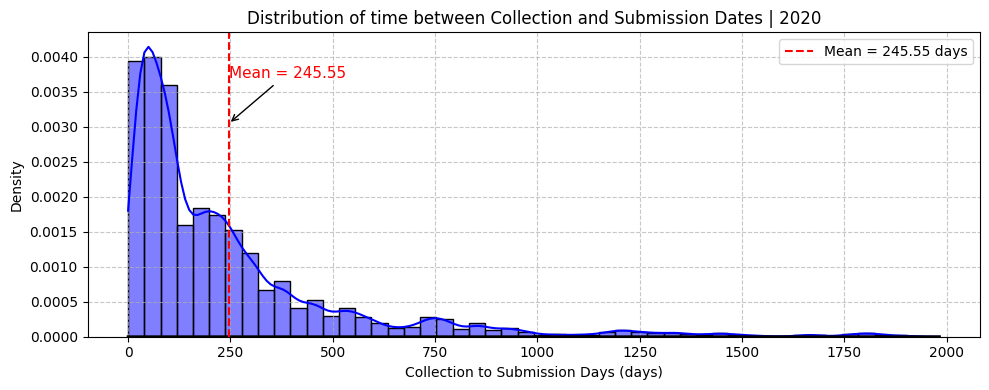

In [46]:
plt.figure(figsize=(10, 4))
sns.histplot(df["collection_to_submission_days"], bins=50, kde=True, color='blue', stat='density')
sns.lineplot(x=sorted(df["collection_to_submission_days"]), 
             y=np.full(df.shape[0], 0), color='black', linewidth=2)
mean_days = df["collection_to_submission_days"].mean()
plt.axvline(mean_days, color='red', linestyle='--', label=f"Mean = {mean_days:.2f} days")

# Place annotation above the mean line, at the top of the plot
ymax = plt.gca().get_ylim()[1]
plt.annotate(f"Mean = {mean_days:.2f}", xy=(mean_days, ymax*0.7), xytext=(mean_days+0.5, ymax*0.85),
             arrowprops=dict(facecolor='red', arrowstyle='->'), color='red', fontsize=11)

plt.xlabel("Collection to Submission Days (days)")
plt.title(f"Distribution of time between Collection and Submission Dates | {YEAR}")
plt.legend()
plt.tight_layout()
plt.grid(axis='both', linestyle='--', alpha=0.7)
plt.savefig(os.path.join(PLOTS_PATH, f"collection_to_submission_days_distribution_{YEAR}.png"), dpi=300)
plt.show()

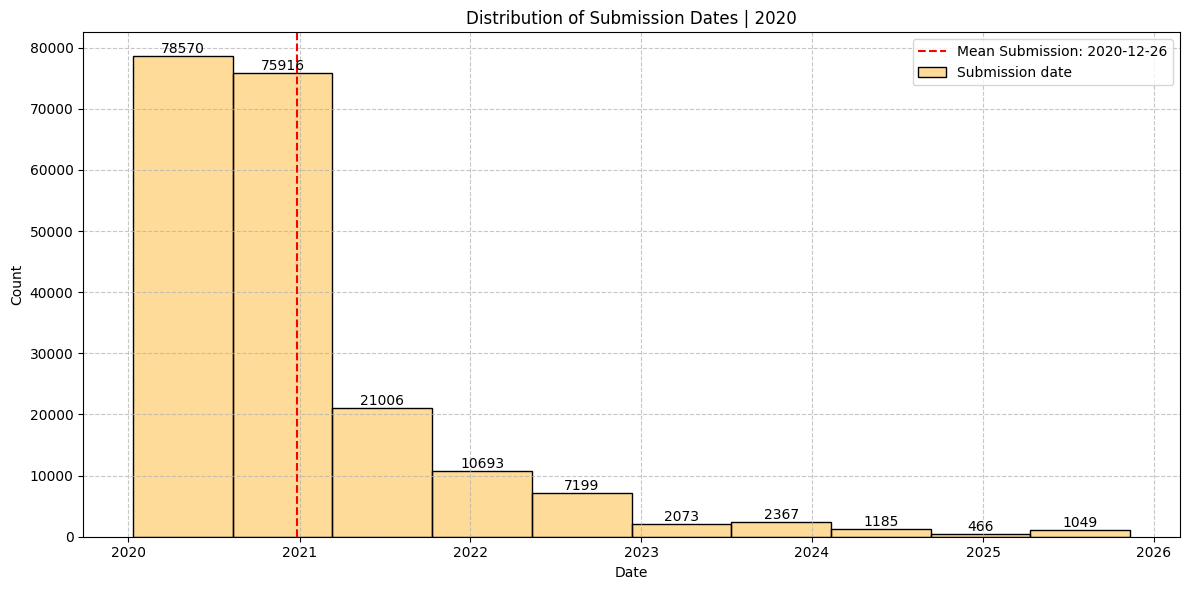

In [47]:
plt.figure(figsize=(12, 6))

# Plot histograms for submission dates
sns.histplot(df["Submission date"], bins=10, color="orange", label="Submission date", kde=False, alpha=0.4)

# Calculate means
mean_submission = df["Submission date"].mean()

# Plot mean lines
plt.axvline(mean_submission, color="red", linestyle="--", label=f"Mean Submission: {mean_submission.date()}")

# Annotate the bars
ax = plt.gca()
for p in ax.patches:
    ax.annotate(str(int(p.get_height())), (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=10)

plt.xlabel("Date")
plt.ylabel("Count")
plt.title(f"Distribution of Submission Dates | {YEAR}")
plt.legend()
plt.tight_layout()
plt.grid(axis='both', linestyle='--', alpha=0.7)
plt.savefig(os.path.join(PLOTS_PATH, f"submission_dates_spread_{YEAR}.png"), dpi=300)
plt.show()

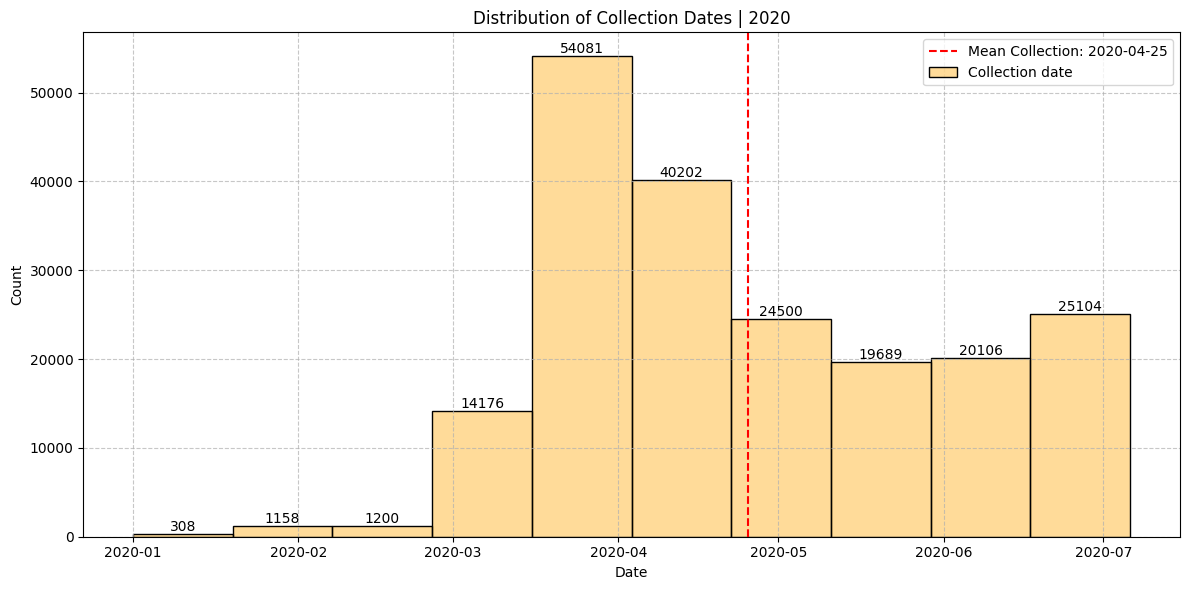

In [48]:
plt.figure(figsize=(12, 6))

# Plot histograms for collection dates
sns.histplot(df["Collection date"], bins=10, color="orange", label="Collection date", kde=False, alpha=0.4)

# Calculate means
mean_collection = df["Collection date"].mean()

# Plot mean lines
plt.axvline(mean_collection, color="red", linestyle="--", label=f"Mean Collection: {mean_collection.date()}")

# Annotate the bars
ax = plt.gca()
for p in ax.patches:
    ax.annotate(str(int(p.get_height())), (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=10)

plt.xlabel("Date")
plt.ylabel("Count")
plt.title(f"Distribution of Collection Dates | {YEAR}")
plt.legend()
plt.tight_layout()
plt.grid(axis='both', linestyle='--', alpha=0.7)
plt.savefig(os.path.join(PLOTS_PATH, f"collection_dates_spread_{YEAR}.png"), dpi=300)
plt.show()

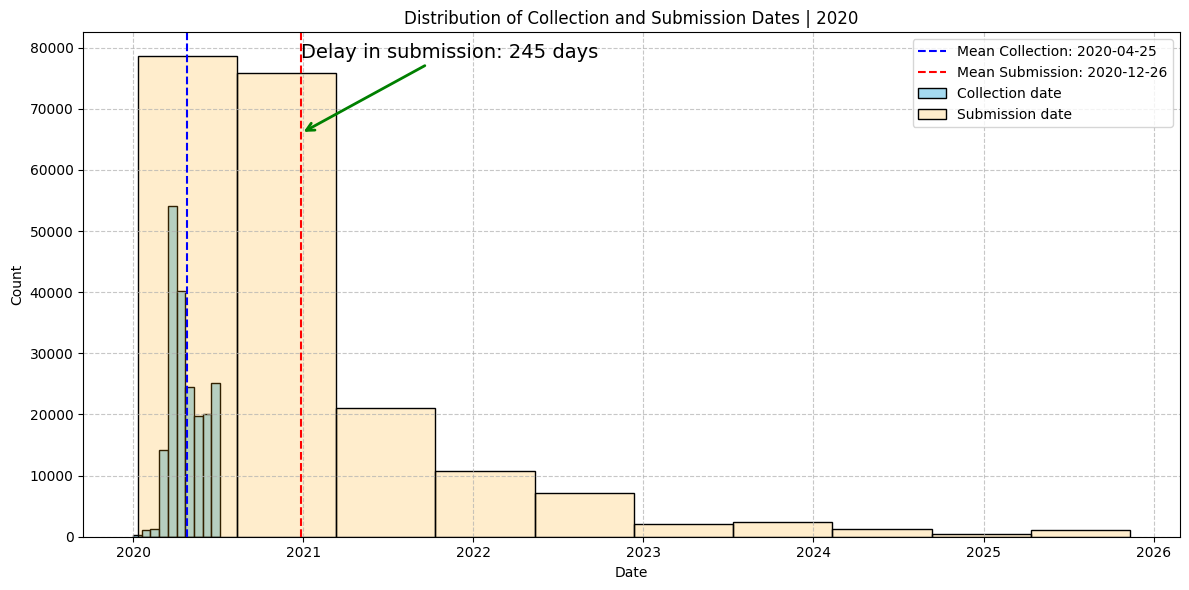

In [49]:
plt.figure(figsize=(12, 6))

# Plot histograms for collection and submission dates
sns.histplot(df["Collection date"], bins=10, color="skyblue", label="Collection date", kde=False)
sns.histplot(df["Submission date"], bins=10, color="orange", label="Submission date", kde=False, alpha=0.2)

# Calculate means
mean_collection = df["Collection date"].mean()
mean_submission = df["Submission date"].mean()

# Plot mean lines
plt.axvline(mean_collection, color="blue", linestyle="--", label=f"Mean Collection: {mean_collection.date()}")
plt.axvline(mean_submission, color="red", linestyle="--", label=f"Mean Submission: {mean_submission.date()}")

# Annotate lead time
lead_time = (mean_submission - mean_collection).days
plt.annotate(
    f"Delay in submission: {lead_time} days",
    xy=(mean_submission, plt.ylim()[1]*0.8),
    xytext=(mean_submission, plt.ylim()[1]*0.95),
    arrowprops=dict(facecolor='green', edgecolor='green', arrowstyle='->', lw=2),
    color="black",
    fontsize=14,
    ha='left'
)

plt.xlabel("Date")
plt.ylabel("Count")
plt.title(f"Distribution of Collection and Submission Dates | {YEAR}")
plt.legend()
plt.tight_layout()
plt.grid(axis='both', linestyle='--', alpha=0.7)
plt.savefig(os.path.join(PLOTS_PATH, f"collection_submission_dates_distribution_{YEAR}.png"), dpi=300)
plt.show()

In [50]:
df["Gender"].value_counts()

Gender
unknown    126850
Male        39113
Female      34561
Name: count, dtype: int64

In [51]:
df["Patient status"].value_counts()

Patient status
unknown                                     183212
Symptomatic                                   4192
Hospitalized                                  3647
Live                                          2700
Released                                      1839
                                             ...  
Rebased                                          1
Hopsitalized                                     1
Non-hospitalized, symptomps: sore throat         1
Suspected Re-infection                           1
Non-hospitalized, symptomps: cough               1
Name: count, Length: 134, dtype: int64

In [52]:
df["Patient age"].value_counts()

Patient age
unknown    128428
23.0         1267
30.0         1262
35.0         1212
32.0         1194
            ...  
2.9             1
3.8             1
1.6             1
51- 60          1
0-4             1
Name: count, Length: 230, dtype: int64

In [53]:
df[~df["Gender"].isin(["Male", "Female", "unknown"])]

,Accession ID,Collection date,Submission date,continent,country,state,city,Gender,Patient status,Patient age,Additional location information,Last vaccinated,Additional host information,clinical_status,hospital_status,severity,who_category,collection_to_submission_days


In [54]:
# Swap the two values in these rows (Patient age and Patent gender)
genders = ["male", "female", "unknown"]
for i, row in df[~df["Gender"].str.lower().isin(genders)].iterrows():
    age = row["Patient age"]
    if age.lower() in genders:
        df.at[i, "Patient age"] = row["Gender"]
        df.at[i, "Gender"] = age

In [55]:
df["Gender"].value_counts()

Gender
unknown    126850
Male        39113
Female      34561
Name: count, dtype: int64

In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 200524 entries, 8434 to 200523
Data columns (total 18 columns):
 #   Column                           Non-Null Count   Dtype         
---  ------                           --------------   -----         
 0   Accession ID                     200524 non-null  object        
 1   Collection date                  200524 non-null  datetime64[ns]
 2   Submission date                  200524 non-null  datetime64[ns]
 3   continent                        200524 non-null  object        
 4   country                          200524 non-null  object        
 5   state                            186578 non-null  object        
 6   city                             52584 non-null   object        
 7   Gender                           200524 non-null  object        
 8   Patient status                   200524 non-null  object        
 9   Patient age                      200524 non-null  object        
 10  Additional location information  6210 non-null

In [57]:
len(set(df.index[(df["clinical_status"].isna()) & (df["hospital_status"].isna()) & (df["severity"].isna()) & (df["who_category"].isna())].tolist()))

108

In [58]:
df[(df["Patient status"].notna()) & (df["clinical_status"].isna())]["Patient status"].value_counts()

Patient status
Infected                                                    100
Healthcare worker                                             6
Comorbidities (more info in Additional host information)      1
Suspected Re-infection                                        1
Name: count, dtype: int64

In [59]:
df["clinical_status"].unique(), df["hospital_status"].unique(), df["severity"].unique(), df["who_category"].unique()

(array(['unknown', 'recovered', 'active', 'suspected', 'dead', nan],
       dtype=object),
 array(['unknown', 'no', 'yes', nan], dtype=object),
 array(['unknown', 'uninfected', 'mild', 'moderate', 'dead', nan, 'severe'],
       dtype=object),
 array(['unknown', 'uninfected', 'hospitalized moderate',
        'ambulatory mild', 'deceased', nan, 'hospitalized severe'],
       dtype=object))

In [60]:
# Mapping Patient status to Clinical status where Clinical status is NaN
infected_mask = (df["Patient status"].str.lower() == "infected") & (df["clinical_status"].isna())
df.loc[infected_mask, "clinical_status"] = "active"
df.loc[infected_mask, "hospital_status"] = "unknown"
df.loc[infected_mask, "severity"] = "unknown"
df.loc[infected_mask, "who_category"] = "unknown"

health_work_mask = (df["Patient status"].str.lower() == "healthcare worker") & (df["clinical_status"].isna())
df.loc[health_work_mask, "clinical_status"] = "unknown"
df.loc[health_work_mask, "hospital_status"] = "unknown"
df.loc[health_work_mask, "severity"] = "unknown"
df.loc[health_work_mask, "who_category"] = "unknown"
comorbid_mask = (df["Patient status"].str.lower().str.startswith("comorbidities")) & (df["clinical_status"].isna())
df.loc[comorbid_mask, "clinical_status"] = "unknown"
df.loc[comorbid_mask, "hospital_status"] = "unknown"
df.loc[comorbid_mask, "severity"] = "unknown"
df.loc[comorbid_mask, "who_category"] = "unknown"

suspected_mask = (df["Patient status"].str.lower() == "suspected re-infection") & (df["clinical_status"].isna())
df.loc[suspected_mask, "clinical_status"] = "suspected"
df.loc[suspected_mask, "hospital_status"] = "unknown"
df.loc[suspected_mask, "severity"] = "unknown"
df.loc[suspected_mask, "who_category"] = "unknown"

In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 200524 entries, 8434 to 200523
Data columns (total 18 columns):
 #   Column                           Non-Null Count   Dtype         
---  ------                           --------------   -----         
 0   Accession ID                     200524 non-null  object        
 1   Collection date                  200524 non-null  datetime64[ns]
 2   Submission date                  200524 non-null  datetime64[ns]
 3   continent                        200524 non-null  object        
 4   country                          200524 non-null  object        
 5   state                            186578 non-null  object        
 6   city                             52584 non-null   object        
 7   Gender                           200524 non-null  object        
 8   Patient status                   200524 non-null  object        
 9   Patient age                      200524 non-null  object        
 10  Additional location information  6210 non-null

In [62]:
# Fill missing values with "unknown"
df["state"].fillna("unknown", inplace=True)
df["city"].fillna("unknown", inplace=True)
df["Additional location information"].fillna("unknown", inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 200524 entries, 8434 to 200523
Data columns (total 18 columns):
 #   Column                           Non-Null Count   Dtype         
---  ------                           --------------   -----         
 0   Accession ID                     200524 non-null  object        
 1   Collection date                  200524 non-null  datetime64[ns]
 2   Submission date                  200524 non-null  datetime64[ns]
 3   continent                        200524 non-null  object        
 4   country                          200524 non-null  object        
 5   state                            200524 non-null  object        
 6   city                             200524 non-null  object        
 7   Gender                           200524 non-null  object        
 8   Patient status                   200524 non-null  object        
 9   Patient age                      200524 non-null  object        
 10  Additional location information  200524 non-nu

## Entries distribution countrywise

We look at number of entries from each country normalised by:
- country's population
- country's per capita income
- reported cases
- reported deaths

First let's create a dictionary containing country's metadata. Countrywise population from [Our World in Data](https://ourworldindata.org/population-growth)

In [63]:
df_pop = pd.read_csv(os.path.join(CLOUD_DATA_FOLDER, "our_world_in_data_population.csv"))
df_pop.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 256 entries, 0 to 255
Data columns (total 75 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   country  256 non-null    object
 1   1950     256 non-null    int64 
 2   1951     256 non-null    int64 
 3   1952     256 non-null    int64 
 4   1953     256 non-null    int64 
 5   1954     256 non-null    int64 
 6   1955     256 non-null    int64 
 7   1956     256 non-null    int64 
 8   1957     256 non-null    int64 
 9   1958     256 non-null    int64 
 10  1959     256 non-null    int64 
 11  1960     256 non-null    int64 
 12  1961     256 non-null    int64 
 13  1962     256 non-null    int64 
 14  1963     256 non-null    int64 
 15  1964     256 non-null    int64 
 16  1965     256 non-null    int64 
 17  1966     256 non-null    int64 
 18  1967     256 non-null    int64 
 19  1968     256 non-null    int64 
 20  1969     256 non-null    int64 
 21  1970     256 non-null    int64 
 22  19

In [64]:
(len(set(df["country"].values.tolist()) -set(df_pop["country"].values.tolist())),
 set(df["country"].values.tolist()) -set(df_pop["country"].values.tolist()))

(11,
 {'Canary Islands',
  'Cote d’Ivoire',
  'Crimea',
  'Czech Republic',
  'Democratic Republic of the Congo',
  'Republic of the Congo',
  'Saint Martin',
  'The Bahamas',
  'Timor-Leste',
  'U.S. Virgin Islands',
  'USA'})

In [65]:
focus = list(set(df["country"].values.tolist()) -set(df_pop["country"].values.tolist()))
df[df["country"].isin(focus)]["country"].value_counts()

country
USA                                 67605
Democratic Republic of the Congo      533
Czech Republic                        266
Canary Islands                         94
Cote d’Ivoire                          40
U.S. Virgin Islands                    21
Timor-Leste                            19
Saint Martin                           10
Republic of the Congo                   7
The Bahamas                             4
Crimea                                  1
Name: count, dtype: int64

A few countries like South Korea, Czech Republic etc have different alternative names used in the dataframes. Let us standardize it using the following snippet. Also, population of Canary Islands is part of that of Spain - included it as Spain.

In [66]:
df["country"] = df["country"].str.replace("USA", "United States")
df["country"] = df["country"].str.replace("Democratic Republic of the Congo", "Democratic Republic of Congo")
df["country"] = df["country"].str.replace("Republic of the Congo", "Congo")
df["country"] = df["country"].str.replace("Timor-Leste", "East Timor")
df["country"] = df["country"].str.replace("Canary Islands", "Spain") # Canary Islands is a part of Spain, not a separate country
df["country"] = df["country"].str.replace("Cote d’Ivoire", "Cote d'Ivoire")

In [67]:
df_pop["country"] = df_pop["country"].str.replace("Czechia", "Czech Republic")
df_pop["country"] = df_pop["country"].str.replace("United States Virgin Islands", "U.S. Virgin Islands")
df_pop["country"] = df_pop["country"].str.replace("Saint Martin (French part)", "Saint Martin")
df_pop["country"] = df_pop["country"].str.replace("Bahamas", "The Bahamas")

In [68]:
(len(set(df["country"].values.tolist()) -set(df_pop["country"].values.tolist())),
 set(df["country"].values.tolist()) -set(df_pop["country"].values.tolist()))

(1, {'Crimea'})

In [69]:
focus = list(set(df["country"].values.tolist()) -set(df_pop["country"].values.tolist()))
df[df["country"].isin(focus)]["country"].value_counts()

country
Crimea    1
Name: count, dtype: int64

In [70]:
countries = df["country"].unique()
country_meta = [{"country":x} for x in countries]
len(country_meta), country_meta[:3]

(167,
 [{'country': 'United States'},
  {'country': 'Hong Kong'},
  {'country': 'China'}])

In [71]:
# Fill in population data in country_meta
for x in tqdm(country_meta, desc="Filling population data"):
    country = x["country"]
    cont = df[df["country"]==country]["continent"].values[0]
    x["continent"] = cont
    if country in df_pop["country"].values.tolist():
        pop = df_pop[df_pop["country"]==country][YEAR].values[0]
        x["population"] = int(pop)
    elif country in ["Crimea"]:
        x["population"] = float("NaN")
country_meta[:3]

Filling population data: 100%|██████████| 167/167 [00:02<00:00, 58.43it/s]


[{'country': 'United States',
  'continent': 'North America',
  'population': 339436106},
 {'country': 'Hong Kong', 'continent': 'Asia', 'population': 7490198},
 {'country': 'China', 'continent': 'Asia', 'population': 1426106040}]

Collect only entries where population is non-zero => exclude Crimea as of now

In [72]:
skip_countries = ["Crimea"]
df1 = df[~df["country"].isin(skip_countries)]
df.shape, df1.shape

((200524, 18), (200523, 18))

In [73]:
df1.columns

Index(['Accession ID', 'Collection date', 'Submission date', 'continent',
       'country', 'state', 'city', 'Gender', 'Patient status', 'Patient age',
       'Additional location information', 'Last vaccinated',
       'Additional host information', 'clinical_status', 'hospital_status',
       'severity', 'who_category', 'collection_to_submission_days'],
      dtype='object')

In [74]:
df1.to_csv(os.path.join(CLOUD_DATA_FOLDER, "Full_data", f"{YEAR}_cleaned.csv"), index=False)

### A. Normalising by country's population
#### A.1. Number of entries from each country

Let's first see how many entries are from different countries grouped by their continent

In [75]:
df_country = pd.DataFrame([x for x in country_meta if x["country"] not in ["Crimea"]])
df_country.shape, df_country[df_country["population"].isnull()].shape

((166, 3), (0, 3))

In [76]:
sorted(df_pop["country"].unique().tolist())

['Afghanistan',
 'Africa (UN)',
 'Albania',
 'Algeria',
 'American Samoa',
 'Americas (UN)',
 'Andorra',
 'Angola',
 'Anguilla',
 'Antigua and Barbuda',
 'Argentina',
 'Armenia',
 'Aruba',
 'Asia (UN)',
 'Australia',
 'Austria',
 'Azerbaijan',
 'Bahrain',
 'Bangladesh',
 'Barbados',
 'Belarus',
 'Belgium',
 'Belize',
 'Benin',
 'Bermuda',
 'Bhutan',
 'Bolivia',
 'Bonaire Sint Eustatius and Saba',
 'Bosnia and Herzegovina',
 'Botswana',
 'Brazil',
 'British Virgin Islands',
 'Brunei',
 'Bulgaria',
 'Burkina Faso',
 'Burundi',
 'Cambodia',
 'Cameroon',
 'Canada',
 'Cape Verde',
 'Cayman Islands',
 'Central African Republic',
 'Chad',
 'Chile',
 'China',
 'Colombia',
 'Comoros',
 'Congo',
 'Cook Islands',
 'Costa Rica',
 "Cote d'Ivoire",
 'Croatia',
 'Cuba',
 'Curacao',
 'Cyprus',
 'Czech Republic',
 'Democratic Republic of Congo',
 'Denmark',
 'Djibouti',
 'Dominica',
 'Dominican Republic',
 'East Timor',
 'Ecuador',
 'Egypt',
 'El Salvador',
 'Equatorial Guinea',
 'Eritrea',
 'Estonia',

In [77]:
exclude = ["Africa (UN)", "Asia (UN)", "Americas (UN)", "Europe (UN)",
            "Oceania (UN)", "World", "High-income countries", "Land-locked developing countries (LLDC)",
            "Latin America and the Caribbean (UN)", "Least developed countries", "Less developed regions",
            "Less developed regions, excluding China", "Less developed regions, excluding least developed countries",
            "Low-income countries", "Lower-middle-income countries", "More developed regions", "Northern America (UN)",
            "Small island developing states (SIDS)", "Upper-middle-income countries"]
df_pop = df_pop[~df_pop["country"].isin(exclude)]
df_pop["country"].nunique()

237

In [78]:
df_merged = pd.merge(df_country, df_pop[["country", str(YEAR)]], on="country", how="right")
df_merged.rename(columns={"2020": "population_2020"}, inplace=True)
df_merged.drop(columns=["population"], inplace=True)
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 237 entries, 0 to 236
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   country          237 non-null    object
 1   continent        166 non-null    object
 2   population_2020  237 non-null    int64 
dtypes: int64(1), object(2)
memory usage: 5.7+ KB


In [79]:
df_merged["country_standard"] = df_merged["country"].apply(standardize_country_name)
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 237 entries, 0 to 236
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   country           237 non-null    object
 1   continent         166 non-null    object
 2   population_2020   237 non-null    int64 
 3   country_standard  237 non-null    object
dtypes: int64(1), object(3)
memory usage: 7.5+ KB


In [80]:
df_merged["continent_x"] = df_merged["country_standard"].apply(get_continent)
df_merged["continent_x"].nunique(), df_merged["continent"].nunique()

(7, 6)

In [81]:
df_merged[df_merged["continent_x"]=="Unknown"]

,country,continent,population_2020,country_standard,continent_x
14,The Bahamas,North America,395827,The Bahamas,Unknown
30,Brunei,Asia,447365,Brunei,Unknown
54,Democratic Republic of Congo,Africa,95989947,Democratic Republic of Congo,Unknown
59,East Timor,Asia,1326002,East Timor,Unknown
111,Kosovo,Europe,1751372,Kosovo,Unknown
136,Micronesia (country),NaN,110883,Micronesia (country),Unknown
162,Palestine,Asia,5069642,Palestine,Unknown
174,Russia,Europe,146371239,Russia,Unknown
177,Saint Helena,NaN,5404,Saint Helena,Unknown
192,Sint Maarten (Dutch part),NaN,40985,Sint Maarten (Dutch part),Unknown


In [82]:
for i, row in df_merged.iterrows():
    if row["continent_x"] == "Unknown" and not pd.isnull(row["continent"]):
        df_merged.at[i, "continent_x"] = row["continent"]
    
    if pd.isnull(row["continent"]) and row["continent_x"] != "Unknown":
        df_merged.at[i, "continent"] = row["continent_x"]

In [83]:
df_merged["continent"].unique(), df_merged["continent_x"].unique()

(array(['Asia', 'Europe', 'Africa', 'Oceania', 'North America',
        'South America', nan], dtype=object),
 array(['Asia', 'Europe', 'Africa', 'Oceania', 'North America',
        'South America', 'Unknown'], dtype=object))

In [84]:
df_merged[df_merged["continent"].isna()]

,country,continent,population_2020,country_standard,continent_x
136,Micronesia (country),NaN,110883,Micronesia (country),Unknown
177,Saint Helena,NaN,5404,Saint Helena,Unknown
192,Sint Maarten (Dutch part),NaN,40985,Sint Maarten (Dutch part),Unknown
229,Vatican,NaN,521,Vatican,Unknown
233,Western Sahara,NaN,549312,Western Sahara,Unknown


In [85]:
for i, row in df_merged.iterrows():
    if row["continent_x"] != "Unknown" and not pd.isnull(row["continent"]):
        if row["continent"] != row["continent_x"]:
            print(f"Mismatch at index {i}: {row['country']} - {row['continent']} vs {row['continent_x']}")

Mismatch at index 10: Aruba - South America vs North America
Mismatch at index 13: Azerbaijan - Europe vs Asia
Mismatch at index 51: Curacao - South America vs North America
Mismatch at index 52: Cyprus - Europe vs Asia
Mismatch at index 180: Saint Martin - North America vs Europe
Mismatch at index 214: Trinidad and Tobago - South America vs North America


We do the following assignment (based on Google search):

- `Aruba` is in `South America`
- `Azerbaijan` mostly in Western Asia. So we assign `Asia`
- `Curacao` is in `South America`
- `Cyprus` is in `Europe`
- `Saint Martin` is in `North America`
- `Trinidad and Tobago` is in `South America`

In [86]:
df_merged.loc[int(df_merged.index[df_merged["country"]=="Aruba"][0]), "continent_x"] = "South America"
df_merged.loc[int(df_merged.index[df_merged["country"]=="Azerbaijan"][0]), "continent"] = "Asia"
df_merged.loc[int(df_merged.index[df_merged["country"]=="Curacao"][0]), "continent_x"] = "South America"
df_merged.loc[int(df_merged.index[df_merged["country"]=="Cyprus"][0]), "continent_x"] = "Europe"
df_merged.loc[int(df_merged.index[df_merged["country"]=="Saint Martin"][0]), "continent_x"] = "North America"
df_merged.loc[int(df_merged.index[df_merged["country"]=="Trinidad and Tobago"][0]), "continent_x"] = "South America"

In [87]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 237 entries, 0 to 236
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   country           237 non-null    object
 1   continent         232 non-null    object
 2   population_2020   237 non-null    int64 
 3   country_standard  237 non-null    object
 4   continent_x       237 non-null    object
dtypes: int64(1), object(4)
memory usage: 9.4+ KB


5 of the 237 entries have `Unknown` continent. Let's see which countries are these.

In [88]:
df_merged[df_merged["continent_x"] == "Unknown"]

,country,continent,population_2020,country_standard,continent_x
136,Micronesia (country),NaN,110883,Micronesia (country),Unknown
177,Saint Helena,NaN,5404,Saint Helena,Unknown
192,Sint Maarten (Dutch part),NaN,40985,Sint Maarten (Dutch part),Unknown
229,Vatican,NaN,521,Vatican,Unknown
233,Western Sahara,NaN,549312,Western Sahara,Unknown


Let's ignore these regions for now.

In [89]:
for i, row in df_merged.iterrows():
    if row["continent_x"] != "Unknown" and not pd.isnull(row["continent"]):
        if row["continent"] != row["continent_x"]:
            print(f"Mismatch at index {i}: {row['country']} - {row['continent']} vs {row['continent_x']}")

In [90]:
df_merged = df_merged[df_merged["continent_x"] != "Unknown"].drop(columns=["continent_x"])
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
Index: 232 entries, 0 to 236
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   country           232 non-null    object
 1   continent         232 non-null    object
 2   population_2020   232 non-null    int64 
 3   country_standard  232 non-null    object
dtypes: int64(1), object(3)
memory usage: 9.1+ KB


In [91]:
df_merged[["country", "continent", "country_standard"]].to_csv(os.path.join(CLOUD_DATA_FOLDER, "Full_data", "country_continent_map.csv"), index=False)

In [92]:
# Insert a new row for Antarctica into df_merged
antarctica_row = {
    "country": "Antarctica",
    "continent": "Antarctica",
    f"population_{YEAR}": 0,
    "country_standard": "Antarctica",
}
df_merged = pd.concat([df_merged, pd.DataFrame([antarctica_row])], ignore_index=True)
df_merged.tail()

,country,continent,population_2020,country_standard
228,Wallis and Futuna,Oceania,11602,Wallis and Futuna
229,Yemen,Asia,36134822,Yemen
230,Zambia,Africa,19059354,Zambia
231,Zimbabwe,Africa,15526837,Zimbabwe
232,Antarctica,Antarctica,0,Antarctica


In [93]:
df_merged["num_entries"] = float("NaN")

for i, row in df_merged.iterrows():
    country = row["country"]
    if country in df1["country"].values:
        df_merged.loc[i, "num_entries"] = df1[df1["country"]==country].shape[0]
df_merged["num_entries"].describe()

count      166.000000
mean      1207.969880
std       6346.357504
min          1.000000
25%         18.000000
50%         60.500000
75%        508.250000
max      67605.000000
Name: num_entries, dtype: float64

Now, we normalize the number of entries by the population of the country to get the comparison to be in a level playing field

In [94]:
# per lakh population
df_merged["num_entries_per_lakh"] = df_merged["num_entries"] / (df_merged[f"population_{YEAR}"] / 1e5)
df_merged.head()

,country,continent,population_2020,country_standard,num_entries,num_entries_per_lakh
0,Afghanistan,Asia,39068933,Afghanistan,9.0,0.023036
1,Albania,Europe,2871900,Albania,NaN,NaN
2,Algeria,Africa,44042041,Algeria,57.0,0.129422
3,American Samoa,Oceania,49732,American Samoa,NaN,NaN
4,Andorra,Europe,77343,Andorra,1.0,1.292942


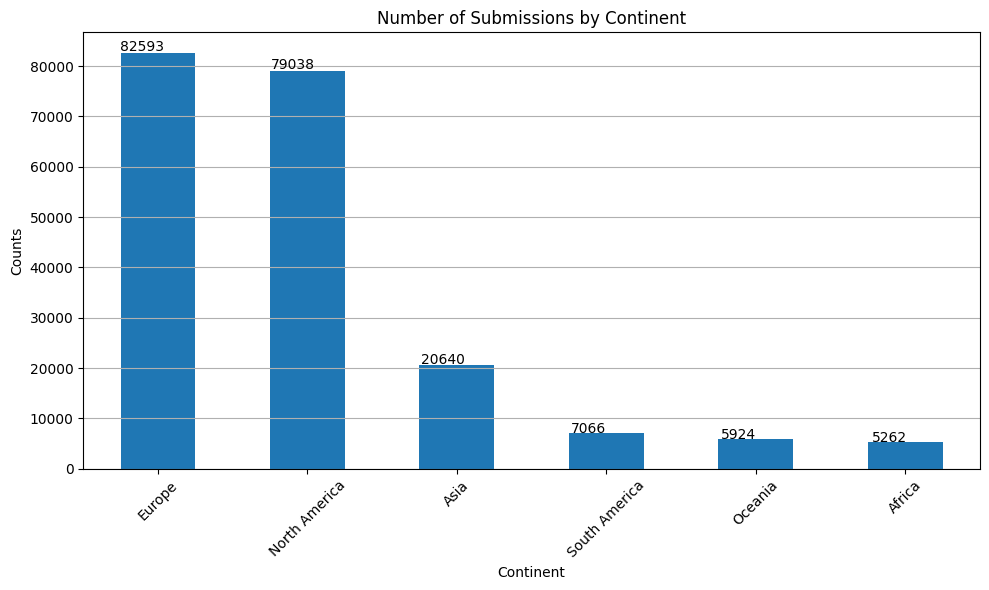

In [95]:
# Plot the bar chart
ax = df1["continent"].value_counts().plot(kind='bar', figsize=(10, 6))
plt.grid()

# Annotate the bars
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() * 1.005, p.get_height() * 1.005))

plt.xlabel('Continent')
plt.xticks(rotation=45)
plt.ylabel('Counts')
plt.title('Number of Submissions by Continent')
plt.grid(axis= 'x')
plt.tight_layout()
plt.show()

In [96]:
df_merged["log_num_entries_per_lakh"] = np.log10(df_merged["num_entries_per_lakh"].replace(0, np.nan))
df_merged["log_num_entries_per_lakh"].describe()

count    166.000000
mean      -0.004530
std        0.899158
min       -2.724411
25%       -0.607606
50%       -0.072552
75%        0.616526
max        2.621101
Name: log_num_entries_per_lakh, dtype: float64

In [97]:
sign = -1 if df_merged["log_num_entries_per_lakh"].min() < 0 else 1
df_merged["log_num_entries_per_lakh"] = df_merged["log_num_entries_per_lakh"] + (df_merged["log_num_entries_per_lakh"].min() * sign)
df_merged["log_num_entries_per_lakh"].describe()

count    166.000000
mean       2.719881
std        0.899158
min        0.000000
25%        2.116805
50%        2.651859
75%        3.340936
max        5.345511
Name: log_num_entries_per_lakh, dtype: float64

In [98]:
# Fill NaN values with a sentinel value (e.g., 0) for visualization purposes
df_merged = col_fillna(df_merged, "log_num_entries_per_lakh", -1.0) # fill with -1.0 for NaN values

custom_scale = [
    [0.0, "#d3d3d3"],    # NaN or sentinel value -> grey (to be masked in z values)
    [0.0001, "#313695"],  # dark blue for low log values
    [0.25,   "#74add1"],  # light blue
    [0.5,    "#ffffbf"],  # yellow (neutral / zero)
    [0.75,   "#f46d43"],  # orange
    [1.0,    "#a50026"]   # dark red for high log values
]

fig = choropleth_world(df_merged,
                        value_column='log_num_entries_per_lakh',
                        color_scale=custom_scale,
                        title=f'Submissions per Lakh Population (World) | Log 10 Scale | {YEAR}',
                        label='Submissions/Lakh (Log 10)',
                        hover_data={
                            f'population_{YEAR}': True,
                            'num_entries': True,
                            'country': False
                        })
fig.write_html(os.path.join(PLOTS_PATH,f"num_entries_per_lakh_log10_world_{YEAR}.html"))
fig.show()

Plot per‐continent maps

In [99]:
# Define custom color scale including a gray value for the sentinel
custom_scale = [
    [0.0, "#d3d3d3"],    # NaN or sentinel value -> grey (to be masked in z values)
    [0.0001, "#313695"],  # dark blue for low log values
    [0.25,   "#74add1"],  # light blue
    [0.5,    "#ffffbf"],  # yellow (neutral / zero)
    [0.75,   "#f46d43"],  # orange
    [1.0,    "#a50026"]   # dark red for high log values
]

fig = choropleth_continent(df_merged,
                           value_column='log_num_entries_per_lakh',
                           color_scale=custom_scale,
                           title=f'Submissions per 1 Lakh Population by Continent | Log 10 Scale | {YEAR}',
                           label='Submissions/Lakh (Log 10)',
                           )
fig.write_html(os.path.join(PLOTS_PATH,f"num_entries_per_lakh_log10_continents_{YEAR}.html"))
fig.show()

#### A.2. Sex distribution across countries

Let's next look at the sex distribution across countries again grouped by continents. We look at sex rather than gender since it is determined at birth and standardized in definitions.

In [100]:
df_merged["sex_m_per_lakh"], df_merged["sex_f_per_lakh"], df_merged["sex_u_per_lakh"] = float('nan'), float('nan'), float('nan')

for i, row in df_merged.iterrows():
    country = row["country"]
    if country in df1["country"].values:
        # Calculate
        df_merged.loc[i, "sex_m_per_lakh"] = (df1[(df1["country"] == country) & (df1["Gender"] == "Male")].shape[0])/(row[f"population_{YEAR}"] / 1e5)
        df_merged.loc[i, "sex_f_per_lakh"] = (df1[(df1["country"] == country) & (df1["Gender"] == "Female")].shape[0])/(row[f"population_{YEAR}"] / 1e5)
        df_merged.loc[i, "sex_u_per_lakh"] = (df1[(df1["country"] == country) & (df1["Gender"] == "unknown")].shape[0])/(row[f"population_{YEAR}"] / 1e5)

Convert to log 10 scale to show variation

In [101]:
df_merged["log_sex_m_per_lakh"] = np.log10(df_merged["sex_m_per_lakh"].replace(0, np.nan))
df_merged["log_sex_m_per_lakh"].describe()

count    142.000000
mean      -0.436463
std        0.868845
min       -2.524410
25%       -1.040522
50%       -0.495858
75%        0.151289
max        2.321203
Name: log_sex_m_per_lakh, dtype: float64

In [102]:
sign = -1 if df_merged["log_sex_m_per_lakh"].min() < 0 else 1
df_merged["log_sex_m_per_lakh"] = df_merged["log_sex_m_per_lakh"] + (df_merged["log_sex_m_per_lakh"].min() * sign)
df_merged["log_sex_m_per_lakh"].describe()

count    142.000000
mean       2.087947
std        0.868845
min        0.000000
25%        1.483888
50%        2.028552
75%        2.675700
max        4.845614
Name: log_sex_m_per_lakh, dtype: float64

For choropleth maps, its better to have 3 different maps one for each sex. First we look at a zoomed out view of the whole world

In [103]:
# World map - distribution of males
df_merged = col_fillna(df_merged, "log_sex_m_per_lakh", -1.0) # fill with -1.0 for NaN values

# Define custom color scale including a gray value for the sentinel
male_scale = [
    [0.0, "#d3d3d3"],    # -1 or missing -> light grey
    [0.0001, "#cbdbfc"],  # very light blue
    [0.01, "#c6dbef"],
    [0.03, "#b3d1e6"],
    [0.06, "#9ecae1"],
    [0.12, "#6bb8d6"],
    [0.25, "#3182bd"],
    [0.5, "#08519c"],
    [1.0, "#08306b"]      # darkest blue
]


fig = choropleth_world(df_merged,
                       value_column="log_sex_m_per_lakh",
                       color_scale=male_scale,
                       title=f"Number of submissions from Males per Lakh Population (World) | Log 10 Scale | {YEAR}",
                       label="Males/1 lakh (Log 10)",
                       hover_data={
                            'sex_m_per_lakh': True,
                            f'population_{YEAR}': True,
                            'country': False
                        })

fig.write_html(os.path.join(PLOTS_PATH,f"num_males_per_lakh_log10_world_{YEAR}.html"))
fig.show()

Now we do for the entries submitted by females

In [104]:
df_merged["log_sex_f_per_lakh"] = np.log10(df_merged["sex_f_per_lakh"].replace(0, np.nan))
df_merged["log_sex_f_per_lakh"].describe()

count    136.000000
mean      -0.514952
std        0.892537
min       -2.724411
25%       -1.069235
50%       -0.549021
75%        0.120802
max        2.316084
Name: log_sex_f_per_lakh, dtype: float64

In [105]:
sign = -1 if df_merged["log_sex_f_per_lakh"].min() < 0 else 1
df_merged["log_sex_f_per_lakh"] = df_merged["log_sex_f_per_lakh"] + (df_merged["log_sex_f_per_lakh"].min() * sign)
df_merged["log_sex_f_per_lakh"].describe()

count    136.000000
mean       2.209459
std        0.892537
min        0.000000
25%        1.655175
50%        2.175390
75%        2.845212
max        5.040494
Name: log_sex_f_per_lakh, dtype: float64

In [106]:
# World map - distribution of females
df_merged = col_fillna(df_merged, "log_sex_f_per_lakh", -1.0) # fill with -1.0 for NaN values

# Define custom color scale including a gray value for the sentinel
female_scale = [
    [0.0, "#d3d3d3"],    # -1 or missing -> light grey
    [0.0001, "#ffb2d5"],  # very light pink
    [0.01, "#ffafcb"],
    [0.05, "#fa9fb5"],
    [0.1, "#f768a1"],
    [0.2, "#c51b8a"],
    [0.4, "#ae017e"],
    [1.0, "#7a0177"]   # darkest pink
]

fig = choropleth_world(df_merged,
                       value_column="log_sex_f_per_lakh",
                       color_scale=female_scale,
                       title=f"Number of submissions from Females per Lakh Population (World) | Log 10 Scale | {YEAR}",
                       label="Females/1 lakh (Log 10)",
                       hover_data={
                            'sex_f_per_lakh': True,
                            f'population_{YEAR}': True,
                            'country': False
                        })

fig.write_html(os.path.join(PLOTS_PATH,f"num_females_per_lakh_log10_world_{YEAR}.html"))
fig.show()

In [107]:
df_merged["log_sex_u_per_lakh"] = np.log10(df_merged["sex_u_per_lakh"].replace(0, np.nan))
df_merged["log_sex_u_per_lakh"].describe()

count    125.000000
mean      -0.478762
std        0.997239
min       -2.514455
25%       -1.170549
50%       -0.504558
75%        0.235033
max        1.767114
Name: log_sex_u_per_lakh, dtype: float64

In [108]:
sign = -1 if df_merged["log_sex_u_per_lakh"].min() < 0 else 1
df_merged["log_sex_u_per_lakh"] = df_merged["log_sex_u_per_lakh"] + (df_merged["log_sex_u_per_lakh"].min() * sign)
df_merged["log_sex_u_per_lakh"].describe()

count    125.000000
mean       2.035693
std        0.997239
min        0.000000
25%        1.343907
50%        2.009897
75%        2.749489
max        4.281569
Name: log_sex_u_per_lakh, dtype: float64

In [109]:
# World map - distribution of females
df_merged = col_fillna(df_merged, "log_sex_u_per_lakh", -1.0) # fill with -1.0 for NaN values

# Define custom color scale including a gray value for the sentinel
unknown_scale = [
    [0.0, "#d3d3d3"],    # missing -> light grey
    [0.0001, "#fff7e6"], # very pale tan
    [0.001, "#fee8c8"],  # very light tan
    [0.01, "#fdd49e"],   # light tan-orange
    [0.05, "#fdbb84"],   # medium golden tan
    [0.1, "#fdae6b"],    # deeper orange
    [0.2, "#fd8d3c"],    # orange
    [0.4, "#e6550d"],    # brown-orange
    [0.7, "#b35806"],    # brown
    [1.0, "#543005"]     # darkest brown
]

fig = choropleth_world(df_merged,
                       value_column="log_sex_u_per_lakh",
                       color_scale=unknown_scale,
                       title=f"Number of Unknown gender per Lakh Population (World) | Log 10 Scale | {YEAR}",
                       label="Missing Sex/1 Lakh (Log 10)",
                       hover_data={
                            'sex_u_per_lakh': True,
                            f'population_{YEAR}': True,
                            'country': False
                        })

fig.write_html(os.path.join(PLOTS_PATH,f"num_unknown_gender_per_lakh_log10_world_{YEAR}.html"))
fig.show()

Now we plot the continent-wise choropleth maps

In [110]:
fig = choropleth_continent(df_merged,
                           value_column='log_sex_m_per_lakh',
                           color_scale=male_scale,
                           title=f"Number of Submissions from males per Lakh Population by Continent | Log 10 Scale | {YEAR}",
                           label="Males/1 Lakh (Log 10)",
                           )

fig.write_html(os.path.join(PLOTS_PATH,f"num_males_per_lakh_log10_continents_{YEAR}.html"))
fig.show()

In [111]:
fig = choropleth_continent(df_merged,
                           value_column='log_sex_f_per_lakh',
                           color_scale=female_scale,
                           title=f"Number of Submissions from females per Lakh Population by Continent | Log 10 Scale | {YEAR}",
                           label="Females/1 Lakh (Log 10)",
                           )

fig.write_html(os.path.join(PLOTS_PATH,f"num_females_per_lakh_log10_continents_{YEAR}.html"))
fig.show()

In [112]:
fig = choropleth_continent(df_merged,
                           value_column='log_sex_u_per_lakh',
                           color_scale=unknown_scale,
                           title=f"Number of Submissions with missing sex per Lakh Population by Continent | Log 10 Scale | {YEAR}",
                           label="Unknown Sex/1 Lakh (Log 10)",
                           )
    
fig.write_html(os.path.join(PLOTS_PATH,f"num_unknown_gender_per_lakh_log10_continents_{YEAR}.html"))
fig.show()

Let's see how the gender ratio is across continents and countries

In [113]:
df_merged["male_female_ratio"] = df_merged["sex_m_per_lakh"] / df_merged["sex_f_per_lakh"].replace(0, np.nan)
df_merged["male_female_ratio"].describe()

count    136.000000
mean       1.561169
std        1.423648
min        0.000000
25%        1.000000
50%        1.168079
75%        1.616228
max       10.000000
Name: male_female_ratio, dtype: float64

In [114]:
df_merged = col_fillna(df_merged, "male_female_ratio", -1.0) # fill with -1.0 for NaN values

custom_rdbu_with_gray = [
    [0.0, "#d3d3d3"],     # Missing / -1 → light gray
    [0.05, "#67001f"],    # Deep red (now at low end)
    [0.1, "#b2182b"],     # Red
    [0.33, "#f7f7f7"],    # White (neutral)
    [0.66, "#2166ac"],    # Blue
    [1.0, "#053061"]      # Deep blue (now at high end)
]

fig = choropleth_world(df_merged,
                       value_column="male_female_ratio",
                       color_scale=custom_rdbu_with_gray,
                       title=f"Male to Female ratio in total submissions (World) | {YEAR}",
                       label="Sex ratio",
                       hover_data={
                            'male_female_ratio': True,
                            f'population_{YEAR}': True,
                            'country': False
                        })
fig.write_html(os.path.join(PLOTS_PATH,f"num_male_female_ratio_world_{YEAR}.html"))
fig.show()

In [115]:
fig = choropleth_continent(df_merged,
                           value_column='male_female_ratio',
                           color_scale=custom_rdbu_with_gray,
                           title="Male to Female ratio in total submissions (continent)",
                           label="Sex ratio",
                            hover_data={"male_female_ratio": True,
                                        f"population_{YEAR}": True,
                                        "country": False}
                           )
fig.write_html(os.path.join(PLOTS_PATH,f"num_male_female_ratio_continents_{YEAR}.html"))
fig.show()

Let us also see which gender submitted majority of the entries for each country on an absolute scale.

In [116]:
fig = plot_dominant_choropleth(
        df1,
        value_column='Gender',
        color_map={
            'Male': '#1f77b4',   # blue
            'Female': "#ff2eb9",   # pink,
            'unknown':'#bdbdbd'  # gray for unknown
        },
        title="Majority Sex"
    )
fig.show()

#### A.3. Patient status distribution across countries

Let's next look at the patient status distribution across countries again grouped by continents

In [117]:
df1["clinical_status"].value_counts(), df1["hospital_status"].value_counts(), df1["severity"].value_counts(), df1["who_category"].value_counts()

(clinical_status
 unknown      183268
 active        13180
 recovered      2298
 dead           1123
 suspected       654
 Name: count, dtype: int64,
 hospital_status
 unknown    184439
 no           9766
 yes          6318
 Name: count, dtype: int64,
 severity
 unknown       183987
 mild            8923
 moderate        4083
 uninfected      2272
 dead            1119
 severe           139
 Name: count, dtype: int64,
 who_category
 unknown                  187028
 ambulatory mild            5204
 hospitalized moderate      4534
 uninfected                 2297
 deceased                   1138
 hospitalized severe         322
 Name: count, dtype: int64)

In [118]:
df1[df1["clinical_status"]=="recovered?"]

,Accession ID,Collection date,Submission date,continent,country,state,city,Gender,Patient status,Patient age,Additional location information,Last vaccinated,Additional host information,clinical_status,hospital_status,severity,who_category,collection_to_submission_days


- In `clinical_status` we group `recovered?` with `recovered`
- In `hospitalization_status` we group `usually yes - requires higher level of care`, `usually yes` and `yes by default` into `yes`; also group `usually no` into `no`
- In `severity` we group  `likely severe?` with `severe` and `unknown - need +RNA to confirm` into `unknown`

In [119]:
df1[df1["severity"].isin(["unknown - need +RNA to confirm", "likely severe?"])]

,Accession ID,Collection date,Submission date,continent,country,state,city,Gender,Patient status,Patient age,Additional location information,Last vaccinated,Additional host information,clinical_status,hospital_status,severity,who_category,collection_to_submission_days


In [120]:
for i, row in df1.iterrows():
    # Clinical status
    if row["clinical_status"] == "recovered?":
        df1.at[i, "clinical_status"] = "recovered"
    
    # Hospitalized status
    if row["hospital_status"] in ["usually yes - requires higher level of care", "usually yes", "yes by default"]:
        df1.at[i, "hospital_status"] = "yes"
    elif row["hospital_status"] == "ususally no":
        df1.at[i, "hospital_status"] = "no"
    
    # Severity
    if row["severity"] == "likely severe?":
        df1.at[i, "severity"] = "severe"
    elif row["severity"] == "unknown - need +RNA to confirm":
        df1.at[i, "severity"] = "unknown"

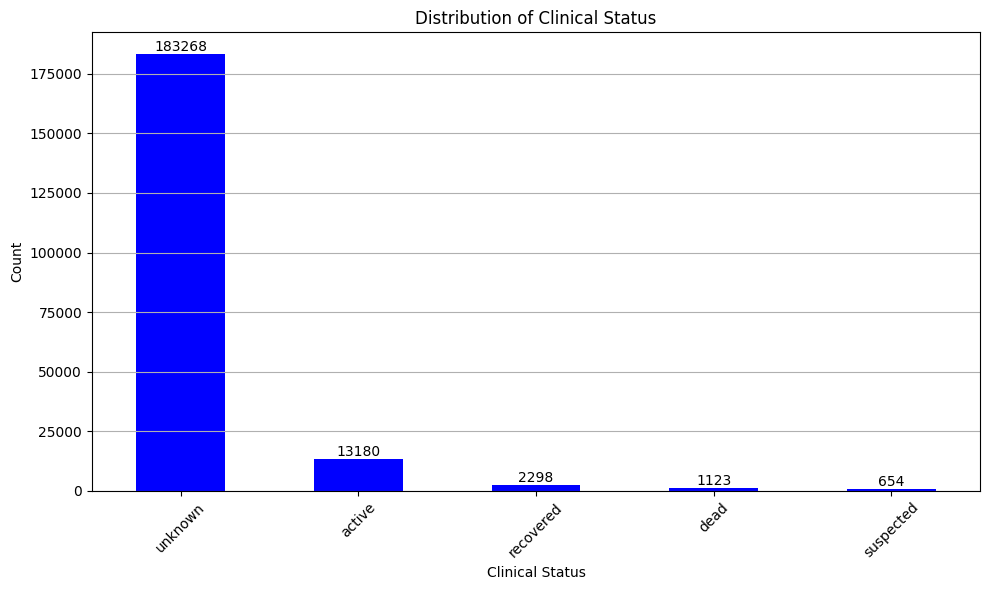

In [121]:
df1["clinical_status"].value_counts().plot(kind='bar', figsize=(10, 6), color='blue')
# Annotate the bars
ax = plt.gca()
for p in ax.patches:
    ax.annotate(str(int(p.get_height())), (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=10)
plt.xlabel('Clinical Status')
plt.ylabel('Count')
plt.title('Distribution of Clinical Status')
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(axis='y')
plt.show()

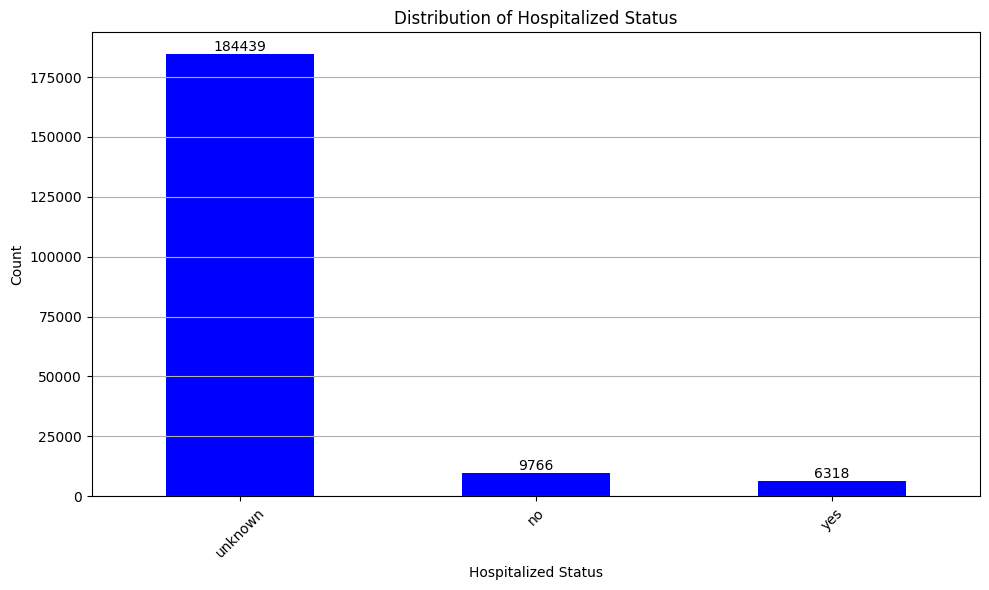

In [122]:
df1["hospital_status"].value_counts().plot(kind='bar', figsize=(10, 6), color='blue')
# Annotate the bars
ax = plt.gca()
for p in ax.patches:
    ax.annotate(str(int(p.get_height())), (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=10)
plt.xlabel('Hospitalized Status')
plt.ylabel('Count')
plt.title('Distribution of Hospitalized Status')
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(axis='y')
plt.show()

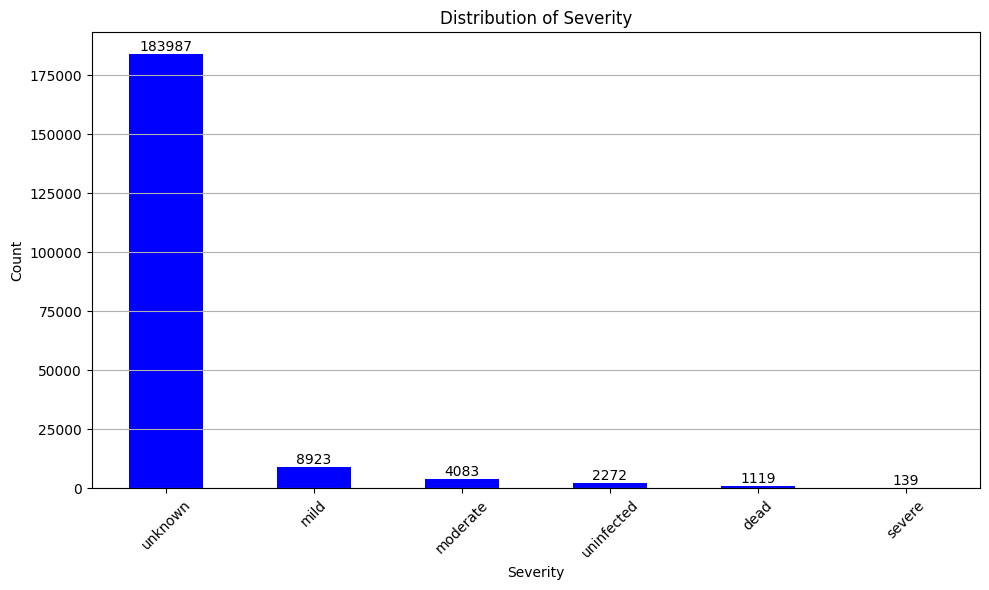

In [123]:
df1["severity"] = df1["severity"].map(str.lower)
df1["severity"].value_counts().plot(kind='bar', figsize=(10, 6), color='blue')
# Annotate the bars
ax = plt.gca()
for p in ax.patches:
    ax.annotate(str(int(p.get_height())), (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=10)
plt.xlabel('Severity')
plt.ylabel('Count')
plt.title('Distribution of Severity')
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(axis='y')
plt.show()

Let's first see how healthy each country is in terms of `clinical_status`

In [124]:
score_map = {"unknown": 0, "recovered": 1, "suspected": 2, "active": 3, "dead": 4}

In [125]:
df1["clinical_status_score"] = df1['clinical_status'].map(score_map)
df1["clinical_status_score"].describe()

count    200523.000000
mean          0.237569
std           0.805747
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           4.000000
Name: clinical_status_score, dtype: float64

In [126]:
df_merged["clinical_status_per_lakh"] = float('nan')

for i, row in df_merged.iterrows():
    country = row["country"]
    if country in df1["country"].values:
        # Calculate
        df_merged.loc[i, "clinical_status_per_lakh"] = (df1[(df1["country"] == country)]["clinical_status_score"].mean())/(row[f"population_{YEAR}"] / 1e5)
df_merged["clinical_status_per_lakh"].describe()

count    166.000000
mean       0.276354
std        2.346129
min        0.000000
25%        0.000000
50%        0.000468
75%        0.007757
max       28.506271
Name: clinical_status_per_lakh, dtype: float64

In [127]:
df_merged["log_clinical_status_per_lakh"] = np.log10(df_merged["clinical_status_per_lakh"].replace(0, np.nan))
df_merged["log_clinical_status_per_lakh"].describe()

count    111.000000
mean      -2.530253
std        1.232133
min       -4.901948
25%       -3.330094
50%       -2.613259
75%       -1.783837
max        1.454940
Name: log_clinical_status_per_lakh, dtype: float64

In [128]:
sign = -1 if df_merged["log_clinical_status_per_lakh"].min() < 0 else 1
df_merged["log_clinical_status_per_lakh"] = df_merged["log_clinical_status_per_lakh"] + (df_merged["log_clinical_status_per_lakh"].min() * sign)
df_merged["log_clinical_status_per_lakh"].describe()

count    111.000000
mean       2.371695
std        1.232133
min        0.000000
25%        1.571854
50%        2.288689
75%        3.118111
max        6.356888
Name: log_clinical_status_per_lakh, dtype: float64

In [129]:
df_merged = col_fillna(df_merged, "log_clinical_status_per_lakh", -1.0) # fill with -1.0 for NaN values

custom_scale = [
    [0.0, "#d3d3d3"],     # NaN or missing → light grey
    [0.0001, "#1a9850"],  # green
    [0.25,   "#a6d96a"],  # light green
    [0.5,    "#ffffbf"],  # yellow
    [0.75,   "#fdae61"],  # orange
    [1.0,    "#a50026"]   # red
]


fig = choropleth_world(df_merged,
                       value_column="log_clinical_status_per_lakh",
                       color_scale=custom_scale,
                       title=f"Clinical status (World) | Log 10 Scale | {YEAR}",
                       label="Avg severity/1 Lakh",
                       hover_data={
                            'clinical_status_per_lakh': True,
                            f'population_{YEAR}': True,
                            'country': False
                        })
fig.write_html(os.path.join(PLOTS_PATH,f"clinical_status_per_lakh_log10_world_{YEAR}.html"))
fig.show()

In [130]:
fig = choropleth_continent(df_merged,
                           value_column='log_clinical_status_per_lakh',
                           color_scale=custom_scale,
                           title=f"Health status (continents) | Log 10 Scale | {YEAR}",
                           label="Avg health score/1 Lakh (Log 10)",
                            hover_data={"clinical_status_per_lakh": True,
                                        f"population_{YEAR}": True,
                                        "country": False}
                           )
fig.write_html(os.path.join(PLOTS_PATH,f"clinical_status_per_lakh_log10_continents_{YEAR}.html"))
fig.show()

Let's see the hospitalization status and later we can see how well-equiped the hospitals in each country are

In [131]:
fig = plot_dominant_choropleth(
        df1,
        value_column='hospital_status',
        color_map={
            'yes': '#1a9850',   # blue
            'no': "#a50026",   # pink,
            'unknown':'#bdbdbd'  # gray for unknown
        },
        title="Majority hospitalized status"
    )
fig.show()

### A.4. Age distribution

Let's see what is the age distribution of the patients across each geographical location. The age format reported here is very varied and requires to be standardized. We refer the age brackets and the classification provided by the [Global Burden of Diseases](https://ourworldindata.org/burden-of-disease):

- `< 5` years old
- `5-14` years old
- `15-49` years old
- `50-69` years old
- `> 70` years old

In [132]:
df1.columns

Index(['Accession ID', 'Collection date', 'Submission date', 'continent',
       'country', 'state', 'city', 'Gender', 'Patient status', 'Patient age',
       'Additional location information', 'Last vaccinated',
       'Additional host information', 'clinical_status', 'hospital_status',
       'severity', 'who_category', 'collection_to_submission_days',
       'clinical_status_score'],
      dtype='object')

In [133]:
df1['age_group'] = df1['Patient age'].apply(map_age_to_group)

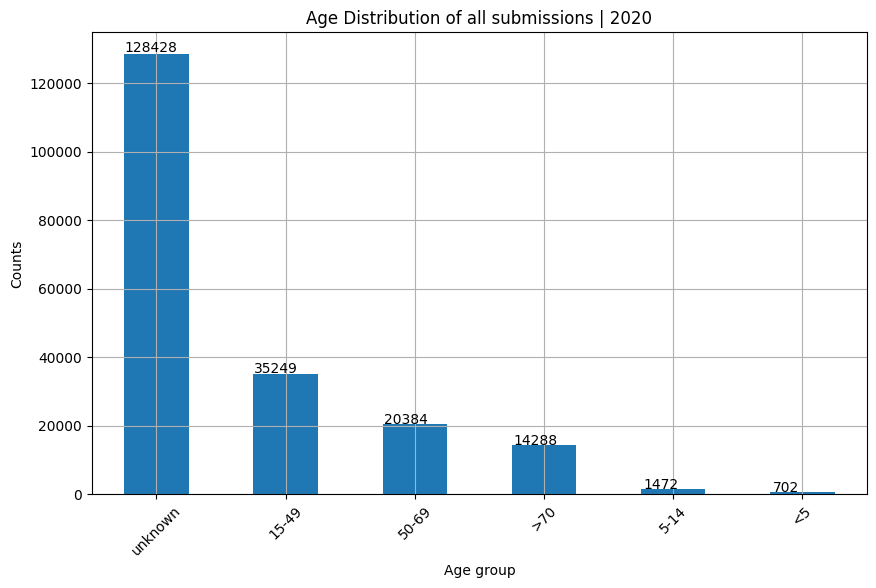

In [134]:
# Plot the bar chart
ax = df1["age_group"].value_counts().plot(kind='bar', figsize=(10, 6))
plt.grid()

# Annotate the bars
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() * 1.005, p.get_height() * 1.005))

plt.xlabel('Age group')
plt.xticks(rotation=45)
plt.ylabel('Counts')
plt.title(f'Age Distribution of all submissions | {YEAR}')
plt.show()

In [135]:
import plotly.express as px

df_grouped = df1.groupby(["country", "age_group"]).size().reset_index(name="count")

df_grouped

,country,age_group,count
0,Afghanistan,15-49,5
1,Afghanistan,unknown,4
2,Algeria,15-49,31
3,Algeria,50-69,15
4,Algeria,<5,1
...,...,...,...
655,Zimbabwe,15-49,76
656,Zimbabwe,5-14,2
657,Zimbabwe,50-69,16
658,Zimbabwe,<5,3


In [136]:
fig = px.choropleth(
    df_grouped,
    locations="country",
    color="count",
    locationmode="country names",
    animation_frame="age_group",
    color_continuous_scale="YlGnBu",
    title=f"Age Group-wise Entries by Country | {YEAR}"
)
# Adjust the order of labels in the slider
# Desired order: '<5', '5-14', '15-49', '50-69', '>70', 'unknown'
desired_order = ['<5', '5-14', '15-49', '50-69', '>70', 'unknown']

# Find the current order of frames
current_order = [frame.name for frame in fig.frames]

# Create a mapping from label to frame
frame_dict = {frame.name: frame for frame in fig.frames}

# Reorder frames
fig.frames = tuple([frame_dict[label] for label in desired_order if label in frame_dict])

# Update slider steps order
for slider in fig.layout.sliders:
    step_dict = {step['label']: step for step in slider['steps']}
    slider['steps'] = [step_dict[label] for label in desired_order if label in step_dict]

fig.update_layout(title_x=0.5, width=1200, height=700)

fig.show()

In [137]:
fig = plot_dominant_choropleth(
    df1,
    value_column='age_group',
    color_map={
        '<5': '#e5f5e0',      # light green
        '5-14': '#a1d99b',
        '15-49': '#41ab5d',   # more contrast
        '50-69': '#238b45',   # more contrast
        '>70': '#005824',     # darkest green for high contrast
        'unknown': '#bdbdbd'  # gray for unknown
    },
    title="Dominant Age Group (Green Shades)"
    )
fig.show()

In [138]:
df_merged.columns

Index(['country', 'continent', 'population_2020', 'country_standard',
       'num_entries', 'num_entries_per_lakh', 'log_num_entries_per_lakh',
       'log_num_entries_per_lakh_filled', 'sex_m_per_lakh', 'sex_f_per_lakh',
       'sex_u_per_lakh', 'log_sex_m_per_lakh', 'log_sex_m_per_lakh_filled',
       'log_sex_f_per_lakh', 'log_sex_f_per_lakh_filled', 'log_sex_u_per_lakh',
       'log_sex_u_per_lakh_filled', 'male_female_ratio',
       'male_female_ratio_filled', 'clinical_status_per_lakh',
       'log_clinical_status_per_lakh', 'log_clinical_status_per_lakh_filled'],
      dtype='object')

In [139]:
df_merged.groupby("continent").agg({"num_entries_per_lakh":"mean","sex_m_per_lakh":"mean","sex_f_per_lakh":"mean",
                                    "sex_u_per_lakh":"mean","male_female_ratio":"mean", "clinical_status_per_lakh":"mean",})

,num_entries_per_lakh,sex_m_per_lakh,sex_f_per_lakh,sex_u_per_lakh,male_female_ratio,clinical_status_per_lakh
continent,,,,,,
Africa,0.899728,0.373860,0.282432,0.243435,1.962534,0.009399
Antarctica,NaN,NaN,NaN,NaN,NaN,NaN
Asia,2.887764,1.671218,0.587101,0.629445,1.954830,0.015188
Europe,20.359883,7.765072,7.561450,5.033362,1.229668,0.144866
North America,7.703182,2.099133,2.097666,3.506384,1.126589,1.935732
Oceania,7.124054,1.529377,1.205314,4.389363,0.999773,0.024074
South America,2.392234,1.041583,0.641024,0.709627,1.188546,0.002384


## Patient status word cloud

In [140]:
from wordcloud import WordCloud

In [141]:
df1.columns

Index(['Accession ID', 'Collection date', 'Submission date', 'continent',
       'country', 'state', 'city', 'Gender', 'Patient status', 'Patient age',
       'Additional location information', 'Last vaccinated',
       'Additional host information', 'clinical_status', 'hospital_status',
       'severity', 'who_category', 'collection_to_submission_days',
       'clinical_status_score', 'age_group'],
      dtype='object')

In [142]:
dfg = df1.groupby("Collection date").count().reset_index()
max_date = dfg.loc[dfg['Accession ID'].idxmax(), 'Collection date']
print("Date with maximum entries:", max_date)

Date with maximum entries: 2020-03-30 00:00:00


In [143]:
dfwc = df1[df1["Collection date"] == pd.to_datetime("2020-03-30")]
# Suppose the column of interest is 'Patient status'
patient_counts = dfwc['Patient status'].value_counts()

# Apply log10 transform with pseudocount (+1 prevents log(0))
weights = np.log10(patient_counts + 1)

In [144]:
dict(patient_counts)

{'unknown': np.int64(3294),
 'Hospitalized': np.int64(82),
 'Symptomatic': np.int64(66),
 'Live': np.int64(33),
 'Inpatient': np.int64(23),
 'Outpatient': np.int64(18),
 'Deceased': np.int64(17),
 'Oropharyngeal swab': np.int64(12),
 'Released': np.int64(10),
 'Acute upper respiratory infection, unspecified': np.int64(3),
 'Mild': np.int64(3),
 'Contact with and exposure to other communicable diseases': np.int64(3),
 'Hospitalized (Moderate)': np.int64(2),
 'Home': np.int64(2),
 'Ambulatory': np.int64(1),
 'Severe / ICU': np.int64(1),
 'Infected': np.int64(1),
 'ICD-10 Disease: J06.9 Acute upper respiratory infection, unspecified': np.int64(1),
 'Quarantine': np.int64(1),
 'Hospitalized (Mild)': np.int64(1),
 'Asymptomatic': np.int64(1),
 'Lived': np.int64(1)}

In [145]:
dfwc["severity"].value_counts()

severity
unknown       3307
mild           132
moderate       108
dead            17
uninfected      11
severe           1
Name: count, dtype: int64

In [146]:
color_map = {
"unknown": "#00515E",
"moderate": "#c68a21",
"mild": "#d6a600",
"uninfected": "#4caf50",
"dead": "#f44336",
"severe": "#ff6200",
}

In [147]:
severity_colors = {}

for i,row in dfwc.iterrows():
    severity = row["severity"]
    if severity in color_map:
        severity_colors[row["Patient status"]] = color_map[severity]
    else:
        severity_colors[row["Patient status"]] = "grey"  # default color for unknown severities

In [148]:
# Custom color function
def color_func(word, font_size, position, orientation, random_state=None, **kwargs):
    # Default to black if word not in mapping
    return severity_colors.get(word, "black")

In [149]:
import os

font_path = os.path.expanduser("~/gcs-buckets/LUCON.TTF")

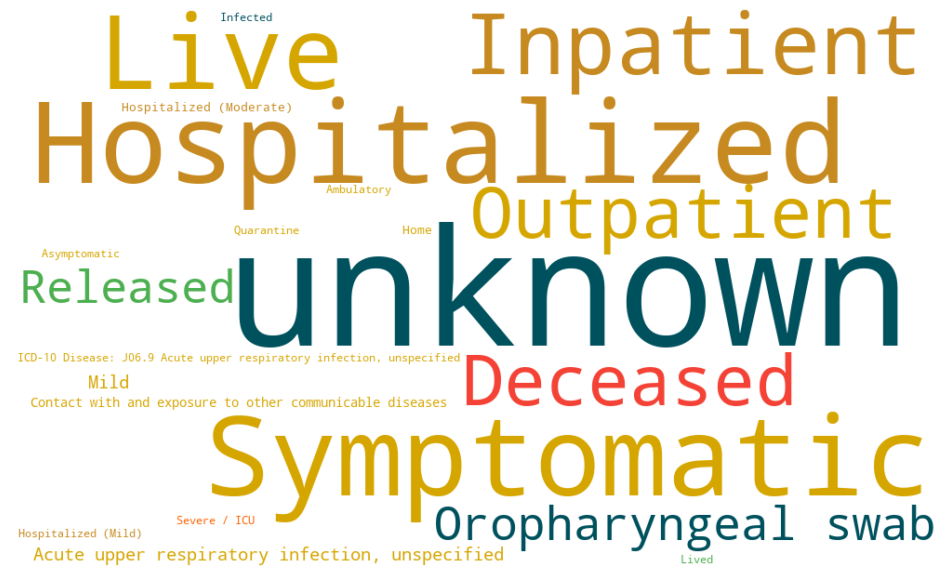

In [150]:
# Power law weights
pw_weights = patient_counts ** 0.25   # 0.5 = sqrt, 0.25 = 4th root

# Square root
sq_weights = np.sqrt(patient_counts)

# Minmax scaled
mm_weights = np.log10(patient_counts + 1)
mm_weights = (mm_weights - mm_weights.min()) / (mm_weights.max() - mm_weights.min())  # 0–1 scale
mm_weights = 1 + mm_weights * 9  # shift into [1,10] range

# Pseudoweights
ps_weights = np.log1p(patient_counts)  # log(1+x), smoother near 0

# Generate word cloud
wc = WordCloud(
    width=1000,
    height=600,
    background_color="white",
    prefer_horizontal=1.0,   # force 100% horizontal
).generate_from_frequencies(pw_weights.to_dict())

# Apply colors
wc.recolor(color_func=color_func)

# Plot
plt.figure(figsize=(12, 8))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.savefig(os.path.join(PLOTS_PATH, "wordcloud_patient_status_2020-03-30_powerlaw.png"))
plt.show()

In [151]:
df1.columns

Index(['Accession ID', 'Collection date', 'Submission date', 'continent',
       'country', 'state', 'city', 'Gender', 'Patient status', 'Patient age',
       'Additional location information', 'Last vaccinated',
       'Additional host information', 'clinical_status', 'hospital_status',
       'severity', 'who_category', 'collection_to_submission_days',
       'clinical_status_score', 'age_group'],
      dtype='object')

In [152]:
df1.to_csv(os.path.join(CLOUD_DATA_FOLDER, "Full_data", f"{YEAR}_cleaned.csv"), index=False)